## **0. Project Title and Aim**


### **Title:**

A Hybrid **Time-Series Framework** for **Early Detection** and **Slow Drift Detection** of **Household Energy Inefficiency** Using **Smart Meter, Weather, and Carbon Intensity Data**

### **Aim:**

To develop a **multi-household time-series framework** that integrates **global forecasting models** with **residual-based monitoring** to detect **early inefficiency events** and **slow drift** in electricity consumption while assessing **environmental impact**.

### **Objectives:**
- To preprocess and integrate **smart meter, weather, and carbon intensity data**
- To analyse **temporal consumption patterns across households**
- To develop **global forecasting models using XGBoost, Random Forest, and TCN**
- To apply a **local LSTM model for selected household-level analysis**
- To detect inefficiency-related drift using **STL, CUSUM, and EWMA**
- To enable **early anomaly detection** and **slow drift detection**
- To evaluate model performance using **MAE, RMSE, and R²**
- To analyse the **carbon impact of excess energy consumption**
- To apply **Explainable AI** using **global SHAP, feature importance, and permutation importance**
- To simulate **pseudo real-time monitoring** and **alert generation**

### **Observation:**

Electricity consumption evolves over time with both **sudden changes** and **gradual behavioural shifts**, influenced by **internal usage patterns** and **external factors such as weather**.

### **Interpretation:**
A hybrid approach combining **global forecasting models (XGBoost, Random Forest, TCN)**, **statistical drift monitoring**, and **Explainable AI** provides a **scalable**, **interpretable**, and **real-world applicable solution** for detecting and managing **household energy inefficiency**.

In [67]:
# ============================================================
# CELL 1: Environment Setup and Library Imports
# ============================================================
# Purpose:
# Initialise the environment and import all required libraries
# for data processing, modelling, drift detection, and visualisation.
# ============================================================

# Install required packages (for Colab/Jupyter environments)
!pip install keras-tcn -q
!pip install xgboost -q
!pip install statsmodels -q
!pip install shap -q
!pip install holidays -q

# ----------------------------
# Core Libraries
# ----------------------------
import os, re, glob, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ----------------------------
# Visualisation
# ----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")

# ----------------------------
# Machine Learning & Evaluation
# ----------------------------
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.ensemble import RandomForestRegressor

# ----------------------------
# Time-Series Analysis
# ----------------------------
from statsmodels.tsa.seasonal import STL

# ----------------------------
# Deep Learning (TCN)
# ----------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tcn import TCN

# ----------------------------
# Advanced Models & Explainability
# ----------------------------
from xgboost import XGBRegressor
import shap
import holidays

# ----------------------------
# Display & Reproducibility
# ----------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [68]:
# ============================================================
# CELL 2: Central Project Configuration
# ============================================================
# Purpose:
# Define key parameters controlling data selection, modelling,
# evaluation, and drift detection to ensure consistency and reproducibility.
# ============================================================

CONFIG = {

    # Data selection
    "n_files": 50,
    "n_households": 300,
    "min_days_per_household": 180,

    # Train / validation / test split
    "val_days": 30,
    "test_days": 60,

    # Time-series modelling
    "lookback": 30,
    "stl_period": 7,

    # Computational control
    "max_compare_houses": 10,

    # Output paths
    "output_dir": "outputs_global",
    "streamlit_dir": "streamlit_app",

    # Drift detection
    "event_quantile": 0.95,
    "consecutive_days": 3,

    # Cross-validation
    "cv_splits": 3,

    # XGBoost hyperparameters
    "xgb_param_grid": {
        "n_estimators": [200, 300],
        "max_depth": [3, 5],
        "learning_rate": [0.03, 0.05],
        "subsample": [0.8],
        "colsample_bytree": [0.8],
        "reg_lambda": [1],
        "reg_alpha": [0, 0.5]
    },

    # Random Forest hyperparameters
    "rf_param_grid": {
        "n_estimators": [150, 250],
        "max_depth": [10, 20],
        "min_samples_leaf": [1, 3],
        "max_features": ["sqrt"]
    }
}

# Create output directories
os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(CONFIG["streamlit_dir"], exist_ok=True)

print(CONFIG)

{'n_files': 50, 'n_households': 300, 'min_days_per_household': 180, 'val_days': 30, 'test_days': 60, 'lookback': 30, 'stl_period': 7, 'max_compare_houses': 10, 'output_dir': 'outputs_global', 'streamlit_dir': 'streamlit_app', 'event_quantile': 0.95, 'consecutive_days': 3, 'cv_splits': 3, 'xgb_param_grid': {'n_estimators': [200, 300], 'max_depth': [3, 5], 'learning_rate': [0.03, 0.05], 'subsample': [0.8], 'colsample_bytree': [0.8], 'reg_lambda': [1], 'reg_alpha': [0, 0.5]}, 'rf_param_grid': {'n_estimators': [150, 250], 'max_depth': [10, 20], 'min_samples_leaf': [1, 3], 'max_features': ['sqrt']}}


In [69]:
# ============================================================
# CELL 3: Data Access and File Paths
# ============================================================
# Purpose:
# Mount Google Drive and define file paths for energy,
# weather, and carbon intensity datasets.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Data paths
energy_glob = "/content/drive/MyDrive/Energy/LCL-June2015v2_*.csv"

tg_path = "/content/drive/MyDrive/Weather/TG_STAID001860.txt"
tx_path = "/content/drive/MyDrive/Weather/TX_STAID001860.txt"
tn_path = "/content/drive/MyDrive/Weather/TN_STAID001860.txt"

carbon_path = "/content/drive/MyDrive/Carbon Intensity Dataset.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
# ============================================================
# CELL 4: Load and Sort Energy Data Files
# ============================================================
# Purpose:
# Retrieve and numerically sort smart meter data files
# to ensure consistent loading order.
# ============================================================

def extract_number(filename: str) -> int:
    match = re.search(r'_(\d+)\.csv$', filename)
    return int(match.group(1)) if match else -1

energy_files = glob.glob(energy_glob)
energy_files_sorted = sorted(energy_files, key=extract_number)

print("Total energy files found:", len(energy_files_sorted))
print("Example files:", energy_files_sorted[:3])

Total energy files found: 168
Example files: ['/content/drive/MyDrive/Energy/LCL-June2015v2_0.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_1.csv', '/content/drive/MyDrive/Energy/LCL-June2015v2_2.csv']


In [71]:
# ============================================================
# CELL 5: Load and Combine Energy Data
# ============================================================
# Purpose:
# Load selected smart meter files, merge into a single dataset,
# and standardise column names for downstream processing.
# ============================================================

files_to_use = energy_files_sorted[:CONFIG["n_files"]]
print("Number of selected files:", len(files_to_use))

energy_parts = []
for fp in files_to_use:
    df = pd.read_csv(fp, low_memory=False)

    # Keep track of source file for traceability across households/files
    df["source_file"] = os.path.basename(fp)

    energy_parts.append(df)

# Combine all files into a single dataframe
energy_raw = pd.concat(energy_parts, ignore_index=True)

# Standardise column names to avoid inconsistencies during merging/modelling
energy_raw.columns = energy_raw.columns.str.strip().str.lower()

print("Combined shape:", energy_raw.shape)
energy_raw.head()

Number of selected files: 50
Combined shape: (50000000, 5)


,lclid,stdortou,datetime,kwh/hh (per half hour),source_file
0,MAC000002,Std,2012-10-12 00:30:00.0000000,0,LCL-June2015v2_0.csv
1,MAC000002,Std,2012-10-12 01:00:00.0000000,0,LCL-June2015v2_0.csv
2,MAC000002,Std,2012-10-12 01:30:00.0000000,0,LCL-June2015v2_0.csv
3,MAC000002,Std,2012-10-12 02:00:00.0000000,0,LCL-June2015v2_0.csv
4,MAC000002,Std,2012-10-12 02:30:00.0000000,0,LCL-June2015v2_0.csv


In [72]:
# ============================================================
# CELL 6: Clean Energy Data
# ============================================================
# Purpose:
# Standardise column names, handle data type conversions,
# and remove invalid records to ensure data quality.
# ============================================================

# Rename columns for consistency and easier referencing
energy_raw = energy_raw.rename(columns={
    "lclid": "LCLid",
    "stdortou": "stdorToU",
    "kwh/hh (per half hour)": "kwh_hh"
})

# Convert to appropriate data types (invalid parsing → NaN)
energy_raw["datetime"] = pd.to_datetime(energy_raw["datetime"], errors="coerce")
energy_raw["kwh_hh"] = pd.to_numeric(energy_raw["kwh_hh"], errors="coerce")

# Remove rows with missing critical fields
energy_raw = energy_raw.dropna(subset=["LCLid", "datetime", "kwh_hh"])

# Extract date for daily-level aggregation
energy_raw["date"] = energy_raw["datetime"].dt.normalize()

print("Cleaned shape:", energy_raw.shape)
print(energy_raw.isna().sum())
energy_raw.head()

Cleaned shape: (49998412, 6)
LCLid          0
stdorToU       0
datetime       0
kwh_hh         0
source_file    0
date           0
dtype: int64


,LCLid,stdorToU,datetime,kwh_hh,source_file,date
0,MAC000002,Std,2012-10-12 00:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
1,MAC000002,Std,2012-10-12 01:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
2,MAC000002,Std,2012-10-12 01:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12
3,MAC000002,Std,2012-10-12 02:00:00,0.000,LCL-June2015v2_0.csv,2012-10-12
4,MAC000002,Std,2012-10-12 02:30:00,0.000,LCL-June2015v2_0.csv,2012-10-12


In [73]:
# ============================================================
# CELL 7: Daily Aggregation
# ============================================================
# Purpose:
# Aggregate half-hourly consumption to daily level and apply
# log transformation to stabilise variance for modelling.
# ============================================================

# Aggregate energy consumption per household per day
energy_daily = (
    energy_raw.groupby(["LCLid", "date"], as_index=False)["kwh_hh"]
    .sum()
    .rename(columns={"kwh_hh": "daily_kWh"})
)

# Log transform to reduce skewness and improve model performance
energy_daily["daily_kWh_log"] = np.log1p(energy_daily["daily_kWh"])

print("Daily shape:", energy_daily.shape)
print("Households:", energy_daily["LCLid"].nunique())
print("Date range:", energy_daily["date"].min(), "to", energy_daily["date"].max())
energy_daily.head()

Daily shape: (1045743, 4)
Households: 1587
Date range: 2011-11-23 00:00:00 to 2014-02-28 00:00:00


,LCLid,date,daily_kWh,daily_kWh_log
0,MAC000002,2012-10-12,7.098,2.092
1,MAC000002,2012-10-13,11.087,2.492
2,MAC000002,2012-10-14,13.223,2.655
3,MAC000002,2012-10-15,10.257,2.421
4,MAC000002,2012-10-16,9.769,2.377


In [74]:
# ============================================================
# CELL 8: Household Coverage Summary
# ============================================================
# Purpose:
# Assess data availability and consistency across households
# by computing coverage duration and consumption statistics.
# ============================================================

df_cov = energy_daily.copy().sort_values(["LCLid", "date"]).reset_index(drop=True)

# Compute per-household coverage and consumption statistics
coverage = df_cov.groupby("LCLid").agg(
    start=("date", "min"),
    end=("date", "max"),
    n_days=("date", "count"),
    mean_kwh=("daily_kWh", "mean"),
    median_kwh=("daily_kWh", "median"),
    std_kwh=("daily_kWh", "std")
).reset_index()

# Estimate full time span and potential missing days
coverage["span_days"] = (coverage["end"] - coverage["start"]).dt.days + 1
coverage["missing_days_est"] = coverage["span_days"] - coverage["n_days"]

# Prioritise households with the most complete data
coverage = coverage.sort_values("n_days", ascending=False)

coverage.head()

,LCLid,start,end,n_days,mean_kwh,median_kwh,std_kwh,span_days,missing_days_est
124,MAC000151,2011-11-23,2014-02-28,829,3.741,3.735,0.698,829,0
130,MAC000157,2011-11-23,2014-02-28,829,11.524,11.088,2.692,829,0
126,MAC000153,2011-11-23,2014-02-28,829,30.751,29.100,11.946,829,0
125,MAC000152,2011-11-23,2014-02-28,829,9.306,8.898,4.713,829,0
123,MAC000150,2011-11-23,2014-02-28,829,9.751,8.783,4.021,829,0


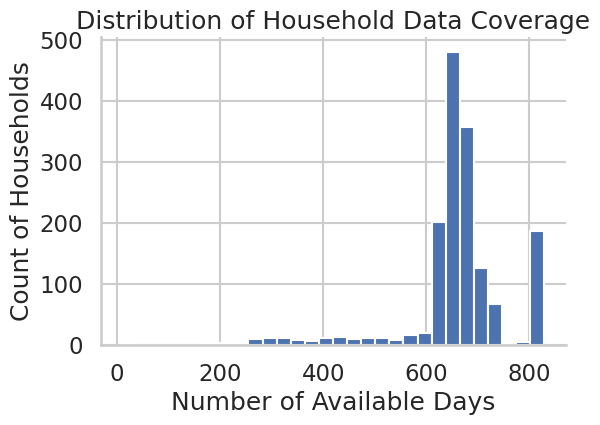

In [11]:
# Visualise distribution of data availability across households
plt.figure(figsize=(6, 4))
plt.hist(coverage["n_days"], bins=30)
plt.title("Distribution of Household Data Coverage")
plt.xlabel("Number of Available Days")
plt.ylabel("Count of Households")
plt.show()

“The distribution of available observations per household was analysed to assess data completeness and guide the selection of households with sufficient temporal coverage.”

In [75]:
# ============================================================
# CELL 9: Load Weather Data
# ============================================================
# Purpose:
# Load and preprocess temperature data, then combine into a
# unified daily weather dataset for feature integration.
# ============================================================

def load_ecad(path: str, value_col: str, q_col: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=20)
    df.columns = ["SOUID", "DATE", value_col, q_col]

    # Convert ECAD date format (YYYYMMDD) to datetime
    df["date"] = pd.to_datetime(df["DATE"], format="%Y%m%d", errors="coerce")

    return df[["date", value_col]]

# Load temperature datasets
tg = load_ecad(tg_path, "TG", "Q_TG")
tx = load_ecad(tx_path, "TX", "Q_TX")
tn = load_ecad(tn_path, "TN", "Q_TN")

# Convert temperature values from tenths of °C to °C
tg["temp_mean"] = tg["TG"] / 10
tx["temp_max"] = tx["TX"] / 10
tn["temp_min"] = tn["TN"] / 10

# Merge all temperature measures into a single dataset
weather = (
    tg[["date", "temp_mean"]]
    .merge(tx[["date", "temp_max"]], on="date", how="inner")
    .merge(tn[["date", "temp_min"]], on="date", how="inner")
)

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (17166, 4)


,date,temp_mean,temp_max,temp_min
0,1979-01-02,-2.600,1.600,-7.500
1,1979-01-03,-2.800,1.300,-7.200
2,1979-01-04,-2.600,-0.300,-6.500
3,1979-01-05,-0.800,5.600,-1.400
4,1979-01-06,-0.500,8.300,-6.600


In [76]:
# ============================================================
# CELL 10: Load Carbon Intensity Data
# ============================================================
# Purpose:
# Load carbon intensity data and aggregate to daily level
# for alignment with energy consumption data.
# ============================================================

carbon_raw = pd.read_csv(carbon_path)

# Convert timestamp and extract date for aggregation
carbon_raw["DATETIME"] = pd.to_datetime(carbon_raw["DATETIME"], errors="coerce")
carbon_raw["date"] = carbon_raw["DATETIME"].dt.normalize()

# Aggregate to daily average carbon intensity
carbon_daily = (
    carbon_raw.groupby("date", as_index=False)["CARBON_INTENSITY"]
    .mean()
    .rename(columns={"CARBON_INTENSITY": "carbon_intensity"})
)

print("Carbon daily shape:", carbon_daily.shape)
carbon_daily.head()


Carbon daily shape: (6263, 2)


,date,carbon_intensity
0,2009-01-01,541.688
1,2009-01-02,571.938
2,2009-01-03,566.750
3,2009-01-04,565.938
4,2009-01-05,586.042


In [77]:
# ============================================================
# CELL 11: Merge Energy, Weather, and Carbon Data
# ============================================================
# Purpose:
# Align external weather and carbon intensity data with the
# daily household energy dataset over the common date range.
# ============================================================

# Restrict external datasets to the energy observation window
start_date = energy_daily["date"].min()
end_date = energy_daily["date"].max()

weather_f = weather[(weather["date"] >= start_date) & (weather["date"] <= end_date)].copy()
carbon_f = carbon_daily[(carbon_daily["date"] >= start_date) & (carbon_daily["date"] <= end_date)].copy()

# Merge daily energy data with weather and carbon features
merged = energy_daily.merge(weather_f, on="date", how="left")
merged2 = merged.merge(carbon_f, on="date", how="left")

print("Merged shape:", merged2.shape)
print("Missing values:")
print(merged2[["temp_mean", "temp_max", "temp_min", "carbon_intensity"]].isna().sum())
merged2.head()

Merged shape: (1045743, 8)
Missing values:
temp_mean           0
temp_max            0
temp_min            0
carbon_intensity    0
dtype: int64


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity
0,MAC000002,2012-10-12,7.098,2.092,12.300,13.500,9.700,527.625
1,MAC000002,2012-10-13,11.087,2.492,9.600,12.900,5.600,556.479
2,MAC000002,2012-10-14,13.223,2.655,7.400,14.200,1.900,547.667
3,MAC000002,2012-10-15,10.257,2.421,8.600,15.900,2.900,549.333
4,MAC000002,2012-10-16,9.769,2.377,12.100,17.500,8.300,540.667


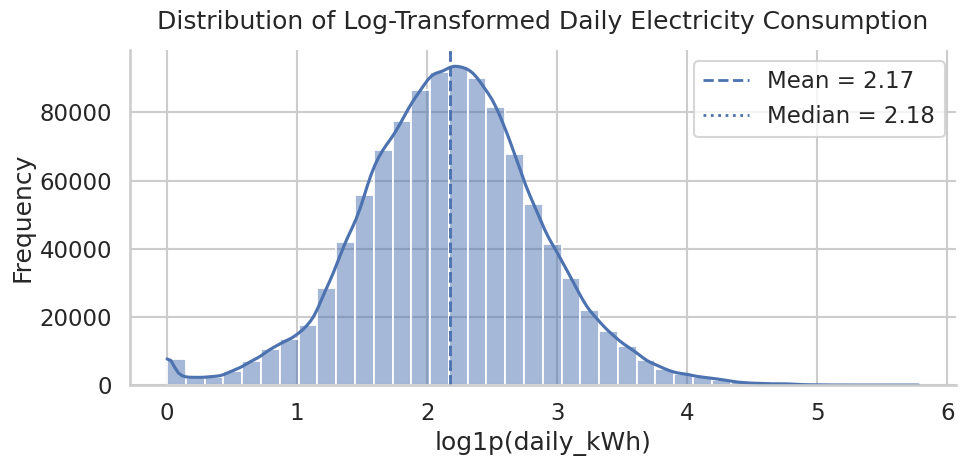

In [78]:
# ============================================================
# CELL 12.1: Distribution of Log Consumption
# ============================================================
# Purpose:
# Visualise the distribution of log-transformed daily consumption
# to assess skewness and central tendency.
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=merged2, x="daily_kWh_log", bins=40, kde=True, ax=ax)

# Highlight mean and median for distribution comparison
mean_val = merged2["daily_kWh_log"].mean()
median_val = merged2["daily_kWh_log"].median()

ax.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.2f}")
ax.axvline(median_val, linestyle=":", linewidth=2, label=f"Median = {median_val:.2f}")

ax.set_title("Distribution of Log-Transformed Daily Electricity Consumption", pad=15)
ax.set_xlabel("log1p(daily_kWh)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

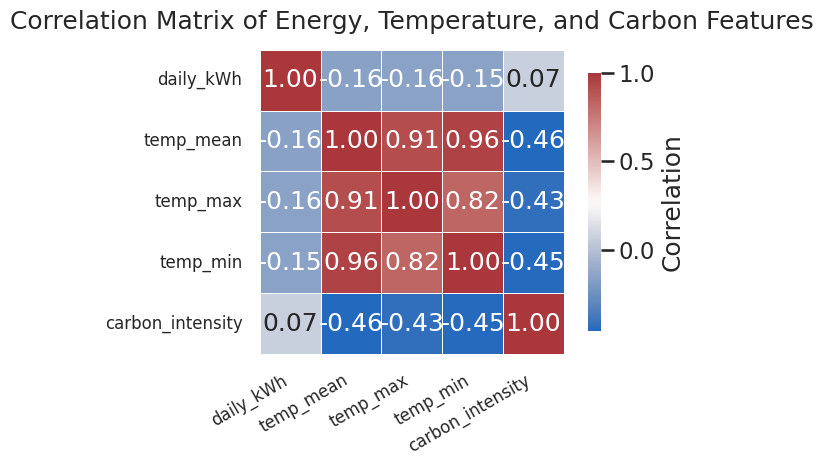

In [79]:
# ============================================================
# CELL 12.2: Correlation Matrix
# ============================================================
# Purpose:
# Examine relationships between energy consumption, temperature,
# and carbon intensity to support feature selection and interpretation.
# ============================================================

corr = merged2[["daily_kWh", "temp_mean", "temp_max", "temp_min", "carbon_intensity"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="vlag", fmt=".2f", linewidths=0.7, square=True,
            cbar_kws={"shrink": 0.85, "label": "Correlation"})

plt.title("Correlation Matrix of Energy, Temperature, and Carbon Features", pad=15)
plt.xticks(fontsize=12, rotation=30, ha="right")
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

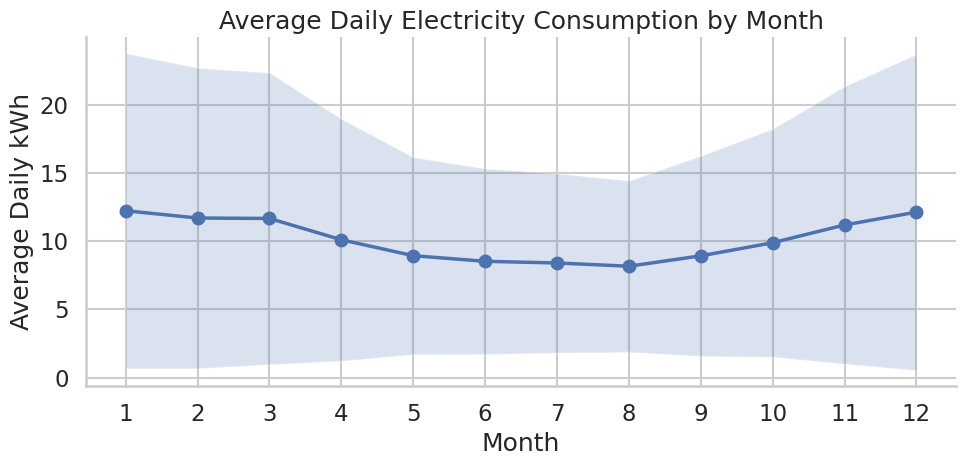

In [80]:
# ============================================================
# CELL 12.3: Monthly Seasonality
# ============================================================
# Purpose:
# Analyse monthly consumption patterns to identify seasonal trends.
# ============================================================

# Compute mean and variability of consumption by month
monthly_stats = merged2.groupby(merged2["date"].dt.month)["daily_kWh"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_stats["date"], monthly_stats["mean"], marker="o", linewidth=2.5)

# Show variability using ±1 standard deviation
plt.fill_between(
    monthly_stats["date"],
    monthly_stats["mean"] - monthly_stats["std"],
    monthly_stats["mean"] + monthly_stats["std"],
    alpha=0.2
)

plt.title("Average Daily Electricity Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily kWh")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

Outlier rows: 61407
Outlier percentage: 5.87 %


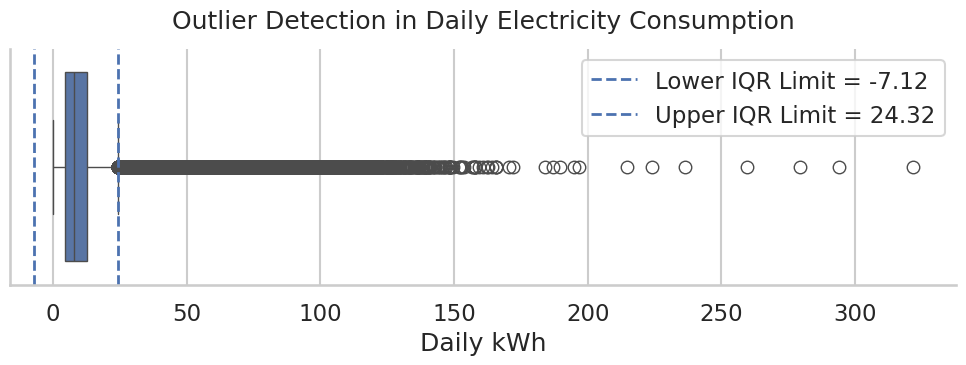

In [81]:
# ============================================================
# CELL 12.4: Outlier Detection
# ============================================================
# Purpose:
# Identify extreme consumption values using the IQR method
# to assess potential anomalies in the dataset.
# ============================================================

# Compute IQR-based thresholds
Q1 = merged2["daily_kWh"].quantile(0.25)
Q3 = merged2["daily_kWh"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Extract potential outliers
outliers = merged2[(merged2["daily_kWh"] < lower) | (merged2["daily_kWh"] > upper)]

print("Outlier rows:", len(outliers))
print("Outlier percentage:", round(100 * len(outliers) / len(merged2), 2), "%")

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=merged2["daily_kWh"], ax=ax)

# Visualise IQR thresholds
ax.axvline(lower, linestyle="--", linewidth=2, label=f"Lower IQR Limit = {lower:.2f}")
ax.axvline(upper, linestyle="--", linewidth=2, label=f"Upper IQR Limit = {upper:.2f}")

ax.set_title("Outlier Detection in Daily Electricity Consumption", pad=15)
ax.set_xlabel("Daily kWh")
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

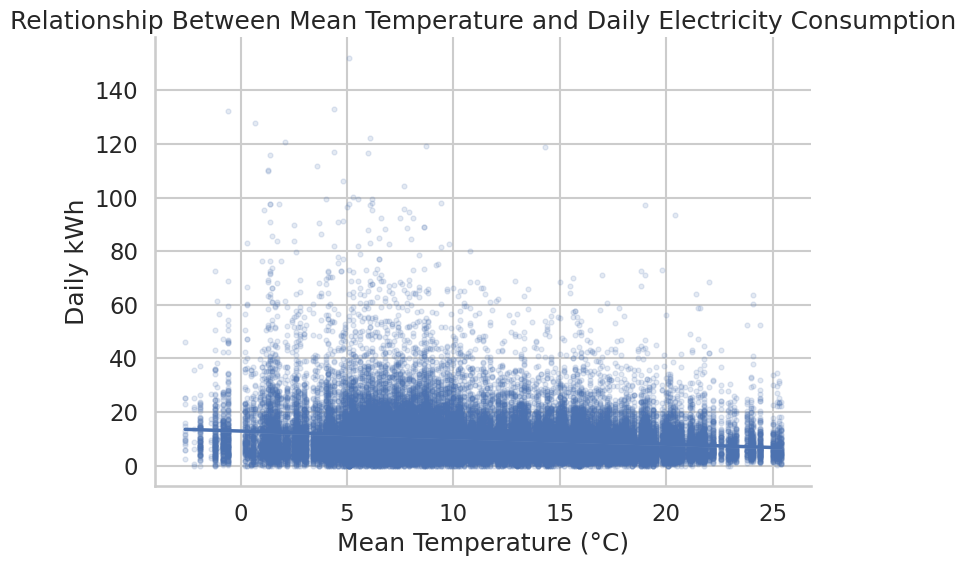

In [82]:
# ============================================================
# CELL 12.5: Temperature vs Energy
# ============================================================
# Purpose:
# Examine the relationship between temperature and energy consumption
# to identify weather-driven usage patterns.
# ============================================================

# Sample data for efficient plotting
sample_df = merged2.sample(min(50000, len(merged2)), random_state=42)

plt.figure(figsize=(8, 6))
sns.regplot(
    data=sample_df,
    x="temp_mean",
    y="daily_kWh",
    scatter_kws={"alpha": 0.15, "s": 12},
    line_kws={"linewidth": 2.5}
)

plt.title("Relationship Between Mean Temperature and Daily Electricity Consumption")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Daily kWh")

plt.tight_layout()
plt.show()

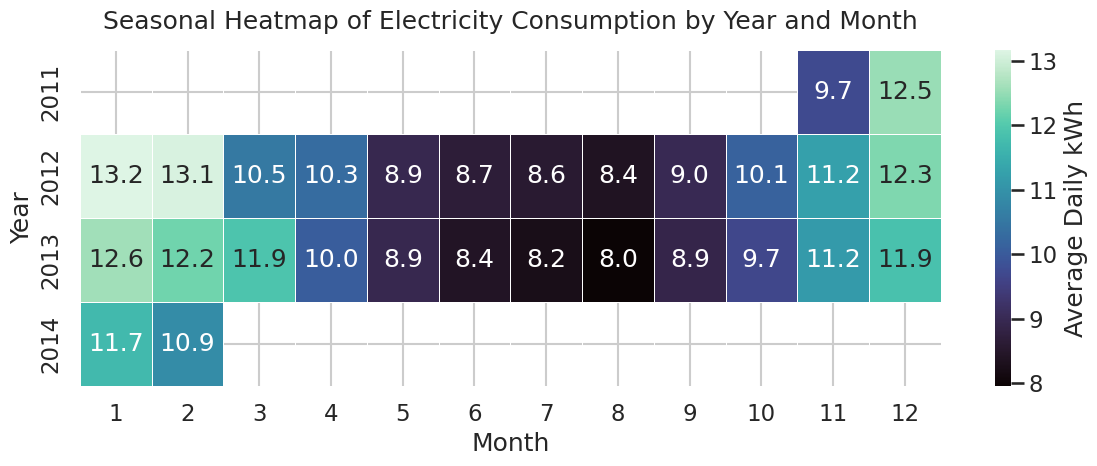

In [83]:
# ============================================================
# CELL 12.6: Seasonal Heatmap
# ============================================================
# Purpose:
# Visualise seasonal patterns in electricity consumption across
# months and years to identify recurring trends.
# ============================================================

season_df = merged2.copy()

# Extract year and month for seasonal aggregation
season_df["year"] = season_df["date"].dt.year
season_df["month"] = season_df["date"].dt.month

# Create pivot table (year × month) for heatmap visualisation
season_pivot = season_df.groupby(["year", "month"])["daily_kWh"].mean().unstack()

plt.figure(figsize=(12, 5))
sns.heatmap(
    season_pivot,
    cmap="mako",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Average Daily kWh"}
)

plt.title("Seasonal Heatmap of Electricity Consumption by Year and Month", pad=15)
plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

In [84]:
# ============================================================
# CELL 12.7: Missingness Check
# ============================================================

missing_summary = merged2.isna().mean().sort_values(ascending=False) * 100
missing_summary

,0
LCLid,0.000
date,0.000
daily_kWh,0.000
daily_kWh_log,0.000
temp_mean,0.000
temp_max,0.000
temp_min,0.000
carbon_intensity,0.000


In [85]:
# ============================================================
# CELL 13: Enhanced Feature Engineering for Time-Series Modelling
# Purpose:
# Create calendar, holiday, weather, lag, rolling, change,
# interaction, and volatility features for multi-household
# forecasting and drift detection.
# ============================================================

df = merged2.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["LCLid", "date"]).reset_index(drop=True)

# ------------------------------------------------------------
# 1. Calendar features
# ------------------------------------------------------------
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

# ------------------------------------------------------------
# 2. UK holiday features
# ------------------------------------------------------------
uk_holidays = holidays.country_holidays("GB", subdiv="ENG")
df["date_only"] = df["date"].dt.date
df["is_holiday"] = df["date_only"].apply(lambda d: int(d in uk_holidays))
df["is_day_before_holiday"] = df["date_only"].apply(
    lambda d: int((pd.Timestamp(d) + pd.Timedelta(days=1)).date() in uk_holidays)
)
df["is_day_after_holiday"] = df["date_only"].apply(
    lambda d: int((pd.Timestamp(d) - pd.Timedelta(days=1)).date() in uk_holidays)
)

# ------------------------------------------------------------
# 3. Cyclical encoding
# ------------------------------------------------------------
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# ------------------------------------------------------------
# 4. Weather and context features
# ------------------------------------------------------------
df["HDD_18"] = np.maximum(0, 18 - df["temp_mean"])
df["temp_range"] = df["temp_max"] - df["temp_min"]
df["is_winter"] = df["month"].isin([12, 1, 2]).astype(int)
df["is_summer"] = df["month"].isin([6, 7, 8]).astype(int)

# ------------------------------------------------------------
# 5. Lag features
# ------------------------------------------------------------
lag_days = [1, 2, 3, 7, 14, 30]
for L in lag_days:
    df[f"lag_{L}"] = df.groupby("LCLid")["daily_kWh"].shift(L)

# ------------------------------------------------------------
# 6. Rolling features without leakage
# ------------------------------------------------------------
g = df.groupby("LCLid")["daily_kWh"]
roll_windows = [7, 14, 30]

for w in roll_windows:
    shifted = g.shift(1)  # prevent future leakage
    df[f"roll_mean_{w}"] = shifted.rolling(w, min_periods=max(3, w // 3)).mean()
    df[f"roll_std_{w}"] = shifted.rolling(w, min_periods=max(3, w // 3)).std()
    df[f"roll_min_{w}"] = shifted.rolling(w, min_periods=max(3, w // 3)).min()
    df[f"roll_max_{w}"] = shifted.rolling(w, min_periods=max(3, w // 3)).max()

# ------------------------------------------------------------
# 7. Difference features (change from previous periods)
# ------------------------------------------------------------
df["diff_1"] = df["daily_kWh"] - df["lag_1"]
df["diff_7"] = df["daily_kWh"] - df["lag_7"]
df["diff_30"] = df["daily_kWh"] - df["lag_30"]

# ------------------------------------------------------------
# 8. Ratio features (current vs recent normal behaviour)
# ------------------------------------------------------------
df["ratio_7"] = df["daily_kWh"] / (df["roll_mean_7"] + 1e-5)
df["ratio_14"] = df["daily_kWh"] / (df["roll_mean_14"] + 1e-5)

# ------------------------------------------------------------
# 9. Interaction features
# ------------------------------------------------------------
df["temp_x_lag1"] = df["temp_mean"] * df["lag_1"]
df["hdd_x_lag1"] = df["HDD_18"] * df["lag_1"]
df["carbon_x_lag1"] = df["carbon_intensity"] * df["lag_1"]

# ------------------------------------------------------------
# 10. Trend and volatility features
# ------------------------------------------------------------
df["trend_7_14"] = df["roll_mean_7"] - df["roll_mean_14"]
df["volatility_7"] = df["roll_std_7"] / (df["roll_mean_7"] + 1e-5)
df["volatility_14"] = df["roll_std_14"] / (df["roll_mean_14"] + 1e-5)

# ------------------------------------------------------------
# 11. Final modelling dataset
# ------------------------------------------------------------
needed = [f"lag_{L}" for L in lag_days] + [f"roll_mean_{w}" for w in roll_windows]

important_cols = (
    needed
    + [f"roll_std_{w}" for w in roll_windows]
    + [
        "temp_mean", "temp_max", "temp_min",
        "carbon_intensity", "HDD_18", "temp_range",
        "diff_1", "diff_7", "diff_30",
        "ratio_7", "ratio_14",
        "temp_x_lag1", "hdd_x_lag1", "carbon_x_lag1",
        "trend_7_14", "volatility_7", "volatility_14"
    ]
)

df_model = df.dropna(subset=important_cols).copy()

# Drop helper column not needed in modelling
df_model = df_model.drop(columns=["date_only"])

print("Enhanced model-ready shape:", df_model.shape)
print("Number of households:", df_model["LCLid"].nunique())
df_model.head()

Enhanced model-ready shape: (998187, 56)
Number of households: 1584


,LCLid,date,daily_kWh,daily_kWh_log,temp_mean,temp_max,temp_min,carbon_intensity,day_of_week,month,year,day_of_month,week_of_year,is_weekend,is_month_start,is_month_end,is_holiday,is_day_before_holiday,is_day_after_holiday,dow_sin,dow_cos,month_sin,month_cos,HDD_18,temp_range,is_winter,is_summer,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,roll_mean_7,roll_std_7,roll_min_7,roll_max_7,roll_mean_14,roll_std_14,roll_min_14,roll_max_14,roll_mean_30,roll_std_30,roll_min_30,roll_max_30,diff_1,diff_7,diff_30,ratio_7,ratio_14,temp_x_lag1,hdd_x_lag1,carbon_x_lag1,trend_7_14,volatility_7,volatility_14
30,MAC000002,2012-11-11,10.699,2.460,6.000,12.700,1.300,541.438,6,11,2012,11,45,1,0,0,0,0,0,-0.782,0.623,-0.500,0.866,12.000,11.400,0,0,13.245,16.722,0.186,14.507,19.629,7.098,12.079,5.487,0.186,16.722,13.561,4.431,0.186,19.629,13.447,4.395,0.186,24.490,-2.546,-3.808,3.601,0.886,0.789,79.470,158.940,"7,171.340",-1.482,0.454,0.327
31,MAC000002,2012-11-12,12.321,2.589,8.000,15.500,3.200,535.438,0,11,2012,12,46,0,0,0,0,0,0,0.000,1.000,-0.500,0.866,10.000,12.300,0,0,10.699,13.245,16.722,15.095,12.779,11.087,11.535,5.394,0.186,16.722,12.923,4.122,0.186,17.822,13.567,4.263,0.186,24.490,1.622,-2.774,1.234,1.068,0.953,85.592,106.990,"5,728.646",-1.388,0.468,0.319
32,MAC000002,2012-11-13,10.264,2.422,11.400,14.200,7.300,525.167,1,11,2012,13,46,0,0,0,0,0,0,0.782,0.623,-0.500,0.866,6.600,6.900,0,0,12.321,10.699,13.245,11.663,13.961,13.223,11.139,5.187,0.186,16.722,12.891,4.125,0.186,17.822,13.608,4.244,0.186,24.490,-2.057,-1.399,-2.959,0.921,0.796,140.459,81.319,"6,470.578",-1.752,0.466,0.320
33,MAC000002,2012-11-14,10.820,2.470,12.000,10.100,9.700,563.188,2,11,2012,14,46,0,0,0,0,0,0,0.975,-0.223,-0.500,0.866,6.000,0.400,0,0,10.264,12.321,10.699,13.137,17.822,10.257,10.939,5.190,0.186,16.722,12.626,4.169,0.186,17.822,13.510,4.288,0.186,24.490,0.556,-2.317,0.563,0.989,0.857,123.168,61.584,"5,780.556",-1.687,0.474,0.330
34,MAC000002,2012-11-15,9.808,2.380,7.100,12.600,4.000,581.688,3,11,2012,15,46,0,0,0,0,0,0,0.434,-0.901,-0.500,0.866,10.900,8.600,0,0,10.820,10.264,12.321,0.186,12.209,9.769,10.608,5.100,0.186,16.722,12.126,3.910,0.186,16.722,13.528,4.274,0.186,24.490,-1.012,9.622,0.039,0.925,0.809,76.822,117.938,"6,293.859",-1.518,0.481,0.322


In [86]:
# ============================================================
# CELL 14: Global Household Selection and Split
# ============================================================
# Purpose:
# Select households with sufficient historical coverage and
# create chronological train, validation, and test splits.
# ============================================================

df_model["date"] = pd.to_datetime(df_model["date"])
merged2["date"] = pd.to_datetime(merged2["date"])

# Compute post-feature-engineering coverage per household
coverage2 = df_model.groupby("LCLid").agg(
    n_days=("date", "count"),
    start=("date", "min"),
    end=("date", "max")
).reset_index()

# Retain households with enough observations for reliable modelling
eligible_households = coverage2.loc[
    coverage2["n_days"] >= CONFIG["min_days_per_household"], "LCLid"
].tolist()

selected_households = eligible_households[:CONFIG["n_households"]]

print("Eligible households:", len(eligible_households))
print("Selected households:", len(selected_households))
print("Example households:", selected_households[:10])

df_model_sel = df_model[df_model["LCLid"].isin(selected_households)].copy()
merged2_sel = merged2[merged2["LCLid"].isin(selected_households)].copy()

# Use a chronological split to preserve temporal order
max_date = df_model_sel["date"].max()
test_start = max_date - pd.Timedelta(days=CONFIG["test_days"] - 1)
val_start = test_start - pd.Timedelta(days=CONFIG["val_days"])

train_global = df_model_sel[df_model_sel["date"] < val_start].copy()
val_global = df_model_sel[(df_model_sel["date"] >= val_start) & (df_model_sel["date"] < test_start)].copy()
test_global = df_model_sel[df_model_sel["date"] >= test_start].copy()

print("Validation starts:", val_start)
print("Test starts:", test_start)
print("Max date:", max_date)
print("Train shape:", train_global.shape)
print("Validation shape:", val_global.shape)
print("Test shape:", test_global.shape)

Eligible households: 1581
Selected households: 300
Example households: ['MAC000002', 'MAC000003', 'MAC000004', 'MAC000006', 'MAC000007', 'MAC000008', 'MAC000009', 'MAC000010', 'MAC000011', 'MAC000012']
Validation starts: 2013-12-01 00:00:00
Test starts: 2013-12-31 00:00:00
Max date: 2014-02-28 00:00:00
Train shape: (194605, 56)
Validation shape: (8022, 56)
Test shape: (15908, 56)


In [87]:
# ============================================================
# CELL 14.1: Split Verification and Valid Household Filtering
# ============================================================
# Purpose:
# Verify chronological train/validation/test splits and retain
# only households with observations in all three partitions.
# ============================================================

# Check for any date leakage across global split boundaries
print("Train rows incorrectly inside validation/test:", (train_global["date"] >= val_start).sum())
print("Validation rows outside validation window:", ((val_global["date"] < val_start) | (val_global["date"] >= test_start)).sum())
print("Test rows incorrectly before test start:", (test_global["date"] < test_start).sum())

# Count split coverage per household
split_check = df_model_sel.groupby("LCLid").apply(
    lambda x: pd.Series({
        "train_rows": (x["date"] < val_start).sum(),
        "val_rows": ((x["date"] >= val_start) & (x["date"] < test_start)).sum(),
        "test_rows": (x["date"] >= test_start).sum()
    })
).reset_index()

print(split_check.head())
print("Households with zero validation rows:", (split_check["val_rows"] == 0).sum())
print("Households with zero test rows:", (split_check["test_rows"] == 0).sum())

# Keep only households present in all three split segments
valid_households = split_check[
    (split_check["train_rows"] > 0) &
    (split_check["val_rows"] > 0) &
    (split_check["test_rows"] > 0)
]["LCLid"].tolist()

print("Households before filtering:", df_model_sel["LCLid"].nunique())
print("Households after filtering:", len(valid_households))

# Filter datasets to valid households only
df_model_sel = df_model_sel[df_model_sel["LCLid"].isin(valid_households)].copy()
merged2_sel = merged2_sel[merged2_sel["LCLid"].isin(valid_households)].copy()
selected_households = valid_households

# Rebuild split datasets after household filtering
train_global = df_model_sel[df_model_sel["date"] < val_start].copy()
val_global = df_model_sel[(df_model_sel["date"] >= val_start) & (df_model_sel["date"] < test_start)].copy()
test_global = df_model_sel[df_model_sel["date"] >= test_start].copy()

print("Final train shape:", train_global.shape)
print("Final validation shape:", val_global.shape)
print("Final test shape:", test_global.shape)

Train rows incorrectly inside validation/test: 0
Validation rows outside validation window: 0
Test rows incorrectly before test start: 0
       LCLid  train_rows  val_rows  test_rows
0  MAC000002         385        30         60
1  MAC000003         620        30         60
2  MAC000004         542        30         60
3  MAC000006         641        30         60
4  MAC000007         403        30         60
Households with zero validation rows: 31
Households with zero test rows: 33
Households before filtering: 300
Households after filtering: 267
Final train shape: (177542, 56)
Final validation shape: (8009, 56)
Final test shape: (15908, 56)


In [92]:
# ============================================================
# CELL 15: Household Selection for Detailed Analysis
# ============================================================
# Purpose:
# Show candidate households (based on variability) and allow
# manual selection for local analysis.
# ============================================================

# Step 1: Get households with high variability
house_stats = df_model_sel.groupby("LCLid")["daily_kWh"].agg(["mean", "std"]).reset_index()
house_stats = house_stats.sort_values("std", ascending=False)

# Step 2: Show top candidates
top_candidates = house_stats.head(10)["LCLid"].tolist()

print("Top 10 households (high variability):")
for i, h in enumerate(top_candidates):
    print(f"{i}: {h}")

# ------------------------------------------------------------
# Step 3: YOU select from above list
# ------------------------------------------------------------
selected_index =5 # 👈 change this (0–9)
SELECTED_HOUSE = top_candidates[selected_index]

print("\nSelected household:", SELECTED_HOUSE)

Top 10 households (high variability):
0: MAC000321
1: MAC000307
2: MAC000034
3: MAC000105
4: MAC000274
5: MAC000249
6: MAC000252
7: MAC000235
8: MAC000312
9: MAC000024

Selected household: MAC000249


In [94]:
# ============================================================
# CELL 16: CUSUM Drift Function
# ============================================================
# Purpose:
# Compute one-sided and two-sided CUSUM statistics on residuals
# to detect sustained upward or downward drift.
# ============================================================

def cusum_drift(residuals, baseline_residuals=None, k_mult=0.5, h_mult=5.0):
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    # Use reference residuals to estimate baseline mean and variability
    if baseline_residuals is None:
        baseline_residuals = residuals

    baseline_residuals = np.asarray(baseline_residuals, dtype=float)
    baseline_residuals = np.nan_to_num(baseline_residuals, nan=0.0)

    mu0 = np.mean(baseline_residuals)
    sigma0 = np.std(baseline_residuals)

    # Return no-drift outputs when baseline variance is zero
    if sigma0 == 0 or np.isnan(sigma0):
        n = len(residuals)
        return np.zeros(n), np.zeros(n), np.zeros(n, dtype=bool), 0.0, 0.0, mu0, sigma0

    k = k_mult * sigma0
    h = h_mult * sigma0

    s_pos = np.zeros(len(residuals))
    s_neg = np.zeros(len(residuals))

    # Track cumulative upward and downward deviation from the baseline
    for i in range(1, len(residuals)):
        x = residuals[i] - mu0
        s_pos[i] = max(0, s_pos[i-1] + x - k)
        s_neg[i] = min(0, s_neg[i-1] + x + k)

    alerts = (s_pos > h) | (s_neg < -h)
    return s_pos, s_neg, alerts, k, h, mu0, sigma0

In [95]:
# ============================================================
# CELL 16.1: EWMA Drift Function
# ============================================================
# Purpose:
# Apply Exponentially Weighted Moving Average (EWMA) on residuals
# to detect gradual (slow) drift in time-series behaviour.
# ============================================================

def ewma_drift(residuals, baseline_residuals=None, alpha=0.3, L=3):
    residuals = np.asarray(residuals, dtype=float)
    residuals = np.nan_to_num(residuals, nan=0.0)

    if len(residuals) == 0:
        return np.array([]), np.array([], dtype=bool), np.nan, np.nan, np.nan, np.nan

    # Use baseline residuals to estimate normal behaviour
    if baseline_residuals is None:
        baseline_residuals = residuals

    baseline_residuals = np.asarray(baseline_residuals, dtype=float)
    baseline_residuals = np.nan_to_num(baseline_residuals, nan=0.0)

    mu0 = np.mean(baseline_residuals)
    sigma0 = np.std(baseline_residuals)

    # Compute EWMA (smoothed residual series)
    ewma = np.zeros(len(residuals))
    ewma[0] = residuals[0]

    for i in range(1, len(residuals)):
        ewma[i] = alpha * residuals[i] + (1 - alpha) * ewma[i-1]

    # Define control limits based on baseline variability
    if sigma0 == 0 or np.isnan(sigma0):
        upper = mu0
        lower = mu0
        alerts = np.zeros(len(ewma), dtype=bool)
    else:
        sigma_ewma = sigma0 * np.sqrt(alpha / (2 - alpha))
        upper = mu0 + L * sigma_ewma
        lower = mu0 - L * sigma_ewma
        alerts = (ewma > upper) | (ewma < lower)

    return ewma, alerts, upper, lower, mu0, sigma0

In [97]:
# ============================================================
# CELL 16.2: STL Baseline
# ============================================================
# Purpose:
# Decompose household consumption into trend, seasonal, and residual
# components to establish an expected baseline for drift monitoring.
# ============================================================

def stl_baseline(df_home, period=7, min_days=60):
    x = df_home[["date", "daily_kWh"]].dropna().sort_values("date").copy()
    x = x.set_index("date").asfreq("D")

    # Fill short gaps to preserve continuity for decomposition
    x["daily_kWh"] = x["daily_kWh"].interpolate(limit=7)

    # Require sufficient history for stable STL decomposition
    if x["daily_kWh"].dropna().shape[0] < min_days:
        return None

    stl = STL(x["daily_kWh"], period=period, robust=True)
    res = stl.fit()

    x["trend"] = res.trend
    x["seasonal"] = res.seasonal
    x["expected_kWh"] = x["trend"] + x["seasonal"]
    x["residual"] = x["daily_kWh"] - x["expected_kWh"]

    return x.reset_index()

In [98]:
# ============================================================
# CELL 16.3: Early Detection Evaluation
# ============================================================
# Purpose:
# Evaluate how early and how reliably alerts are triggered
# relative to sustained inefficiency events in the test period.
# ============================================================

def evaluate_early_detection(home_test, alert_col="cusum_alert", residual_col="residual_test",
                             baseline_residuals=None, consecutive_days=3, event_quantile=0.95):
    temp = home_test.copy()

    if temp.empty:
        return {
            "event_date": pd.NaT,
            "first_alert": pd.NaT,
            "lead_time_days": np.nan,
            "false_alarm_rate": np.nan,
            "stability_score": np.nan,
            "event_threshold": np.nan,
        }

    # Use baseline residuals to define the event threshold
    if baseline_residuals is None or len(baseline_residuals) == 0:
        baseline_residuals = temp[residual_col].dropna().values

    threshold = np.quantile(baseline_residuals, event_quantile) if len(baseline_residuals) > 0 else np.nan

    # Define an event as sustained high residuals over consecutive days
    temp["event_flag"] = (temp[residual_col] > threshold).astype(int)
    temp["event_run"] = temp["event_flag"].rolling(consecutive_days).sum()

    event_date = temp.loc[temp["event_run"] >= consecutive_days, "date"].min()
    first_alert = temp.loc[temp[alert_col] == True, "date"].min()

    # Positive lead time indicates warning before the event
    lead_time = (event_date - first_alert).days if pd.notna(event_date) and pd.notna(first_alert) else np.nan

    # Measure alert frequency before the event as false-alarm behaviour
    if pd.notna(event_date):
        false_alarms = temp[(temp[alert_col] == True) & (temp["date"] < event_date)]
        false_alarm_rate = len(false_alarms) / len(temp) if len(temp) > 0 else np.nan
    else:
        false_alarm_rate = temp[alert_col].sum() / len(temp) if len(temp) > 0 else np.nan

    stability_score = temp[alert_col].rolling(consecutive_days).sum().max()

    return {
        "event_date": event_date,
        "first_alert": first_alert,
        "lead_time_days": lead_time,
        "false_alarm_rate": false_alarm_rate,
        "stability_score": stability_score,
        "event_threshold": threshold,
    }

In [99]:
# ============================================================
# CELL 16.4: Regression Metrics
# ============================================================
# Purpose:
# Compute standard regression metrics to evaluate model performance.
# ============================================================

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

In [100]:
# ============================================================
# CELL 16.5: Utility Functions
# ============================================================
# Purpose:
# Define reusable helper functions for time-series cross-validation,
# drift detection, forecasting metrics, alert evaluation, and
# carbon impact summarisation.
# ============================================================

def run_timeseries_cv_model(train_df, feature_cols, target_col, param_grid, model_type="xgb", n_splits=3):
    """Run time-series cross-validation and return the best parameter set."""
    train_sorted = train_df.sort_values("date").reset_index(drop=True)
    X_cv = train_sorted[feature_cols]
    y_cv = train_sorted[target_col]
    tscv = TimeSeriesSplit(n_splits=n_splits)

    best_score = np.inf
    best_params = None
    cv_rows = []

    for params in ParameterGrid(param_grid):
        fold_maes = []

        for tr_idx, va_idx in tscv.split(X_cv):
            X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
            y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

            if model_type == "xgb":
                model = XGBRegressor(
                    random_state=42,
                    objective="reg:squarederror",
                    n_jobs=-1,
                    **params
                )
            elif model_type == "rf":
                model = RandomForestRegressor(
                    random_state=42,
                    n_jobs=-1,
                    **params
                )
            else:
                raise ValueError("model_type must be 'xgb' or 'rf'")

            model.fit(X_tr, y_tr)
            pred_va = model.predict(X_va)
            fold_maes.append(mean_absolute_error(y_va, pred_va))

        avg_mae = float(np.mean(fold_maes))
        cv_rows.append({
            "model_type": model_type,
            "params": str(params),
            "cv_mae": avg_mae
        })

        if avg_mae < best_score:
            best_score = avg_mae
            best_params = params

    cv_results = pd.DataFrame(cv_rows).sort_values("cv_mae").reset_index(drop=True)
    return best_params, best_score, cv_results


def apply_drift_methods(df_res, residual_col, prefix, baseline_by_house=None):
    """Apply CUSUM and EWMA drift detection household by household."""
    out = []

    for hid, g in df_res.groupby("LCLid"):
        g = g.sort_values("date").copy()
        baseline_residuals = None

        # Use household-specific baseline residuals when available
        if baseline_by_house is not None and hid in baseline_by_house:
            baseline_residuals = baseline_by_house[hid]

        r = g[residual_col].fillna(0).values

        cusum_pos, cusum_neg, cusum_alert, k, h, _, _ = cusum_drift(
            r,
            baseline_residuals=baseline_residuals
        )
        ewma_vals, ewma_alert, ewma_upper, ewma_lower, _, _ = ewma_drift(
            r,
            baseline_residuals=baseline_residuals
        )

        g[f"{prefix}_cusum_pos"] = cusum_pos
        g[f"{prefix}_cusum_neg"] = cusum_neg
        g[f"{prefix}_cusum_alert"] = cusum_alert
        g[f"{prefix}_cusum_k"] = k
        g[f"{prefix}_cusum_h"] = h

        g[f"{prefix}_ewma"] = ewma_vals
        g[f"{prefix}_ewma_alert"] = ewma_alert
        g[f"{prefix}_ewma_upper"] = ewma_upper
        g[f"{prefix}_ewma_lower"] = ewma_lower

        out.append(g)

    return pd.concat(out, ignore_index=True)


def compute_forecast_metrics(df_pred, actual_col, pred_col, model_name):
    """Compute household-level regression metrics for forecasts."""
    rows = []

    for hid, g in df_pred.groupby("LCLid"):
        m = regression_metrics(g[actual_col].values, g[pred_col].values)
        rows.append({"LCLid": hid, "model": model_name, **m})

    return pd.DataFrame(rows)


def evaluate_alerts(df_alerts, alert_col, residual_col, method_name, baseline_by_house=None):
    """Evaluate early-warning performance for each household."""
    rows = []

    for hid, g in df_alerts.groupby("LCLid"):
        baseline_residuals = None

        if baseline_by_house is not None and hid in baseline_by_house:
            baseline_residuals = baseline_by_house[hid]

        ev = evaluate_early_detection(
            g.sort_values("date"),
            alert_col=alert_col,
            residual_col=residual_col,
            baseline_residuals=baseline_residuals,
            consecutive_days=CONFIG["consecutive_days"],
            event_quantile=CONFIG["event_quantile"]
        )

        rows.append({"LCLid": hid, "method": method_name, **ev})

    return pd.DataFrame(rows)


def carbon_impact_summary(df_res, residual_col, model_name):
    """Summarise excess energy use and associated carbon impact."""
    temp = df_res.copy()

    # Only positive residuals are treated as excess consumption
    temp["positive_excess_kwh"] = temp[residual_col].clip(lower=0)
    temp["excess_carbon_g"] = temp["positive_excess_kwh"] * temp["carbon_intensity"]

    out = (
        temp.groupby("LCLid")
        .agg(
            excess_energy_kwh=("positive_excess_kwh", "sum"),
            excess_carbon_g=("excess_carbon_g", "sum")
        )
        .reset_index()
    )

    out["model"] = model_name
    return out

In [101]:
# ============================================================
# CELL 17: Encode Household ID and Define Feature Columns
# ============================================================
# Purpose:
# Encode household IDs and prepare feature/target splits
# for global modelling.
# ============================================================

# Encode household ID as numeric feature
le_house = LabelEncoder()
df_model_sel["LCLid_code"] = le_house.fit_transform(df_model_sel["LCLid"])

# Recreate chronological splits (after any filtering changes)
train_global = df_model_sel[df_model_sel["date"] < val_start].copy()
val_global = df_model_sel[
    (df_model_sel["date"] >= val_start) & (df_model_sel["date"] < test_start)
].copy()
test_global = df_model_sel[df_model_sel["date"] >= test_start].copy()

# Define feature columns (exclude identifiers and targets)
feature_cols = [
    c for c in df_model_sel.columns
    if c not in ["LCLid", "date", "daily_kWh", "daily_kWh_log"]
]

# Create train/validation/test matrices
X_train = train_global[feature_cols]
y_train = train_global["daily_kWh"]

X_val = val_global[feature_cols]
y_val = val_global["daily_kWh"]

X_test = test_global[feature_cols]
y_test = test_global["daily_kWh"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (177542, 53)
X_val: (8009, 53)
X_test: (15908, 53)


In [102]:
# ============================================================
# CELL 18: Global XGBoost with Time-Series Cross-Validation
# ============================================================
# Purpose:
# Tune a global XGBoost model using time-series cross-validation,
# generate household-level forecasts, and apply drift detection
# on test residuals.
# ============================================================

# Select best hyperparameters using chronological cross-validation
best_xgb_params, best_xgb_cv_mae, xgb_cv_results = run_timeseries_cv_model(
    train_df=train_global,
    feature_cols=feature_cols,
    target_col="daily_kWh",
    param_grid=CONFIG["xgb_param_grid"],
    model_type="xgb",
    n_splits=CONFIG["cv_splits"]
)

print("Best XGB params:", best_xgb_params)
print("Best XGB CV MAE:", best_xgb_cv_mae)

# Retrain on train + validation data before final test evaluation
trainval_global = (
    pd.concat([train_global, val_global], axis=0)
    .sort_values(["date", "LCLid"])
    .reset_index(drop=True)
)
X_trainval = trainval_global[feature_cols]
y_trainval = trainval_global["daily_kWh"]

global_xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1,
    **best_xgb_params
)
global_xgb.fit(X_trainval, y_trainval)

# Generate test forecasts and residuals
test_global_xgb = test_global[["LCLid", "date", "daily_kWh", "carbon_intensity"]].copy()
test_global_xgb["xgb_pred"] = global_xgb.predict(X_test)
test_global_xgb["xgb_residual"] = test_global_xgb["daily_kWh"] - test_global_xgb["xgb_pred"]

# Use validation residuals as household-specific drift baselines
val_global_xgb = val_global[["LCLid", "date", "daily_kWh"]].copy()
val_global_xgb["xgb_pred"] = global_xgb.predict(X_val)
val_global_xgb["xgb_residual"] = val_global_xgb["daily_kWh"] - val_global_xgb["xgb_pred"]

xgb_baseline_by_house = {
    hid: g["xgb_residual"].dropna().values
    for hid, g in val_global_xgb.groupby("LCLid")
}

# Apply residual-based drift monitoring on test data
test_global_xgb = apply_drift_methods(
    test_global_xgb,
    "xgb_residual",
    "xgb",
    baseline_by_house=xgb_baseline_by_house
)

# Evaluate forecasting accuracy, alert performance, and carbon impact
xgb_metrics_all = compute_forecast_metrics(
    test_global_xgb, "daily_kWh", "xgb_pred", "XGBoost"
)
xgb_cusum_eval = evaluate_alerts(
    test_global_xgb, "xgb_cusum_alert", "xgb_residual", "XGB_CUSUM",
    baseline_by_house=xgb_baseline_by_house
)
xgb_ewma_eval = evaluate_alerts(
    test_global_xgb, "xgb_ewma_alert", "xgb_residual", "XGB_EWMA",
    baseline_by_house=xgb_baseline_by_house
)
carbon_xgb = carbon_impact_summary(test_global_xgb, "xgb_residual", "XGBoost")

Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 1, 'subsample': 0.8}
Best XGB CV MAE: 0.18813598377913557


In [103]:
# ============================================================
# CELL 19: Global Random Forest with Time-Series Cross-Validation
# ============================================================
# Purpose:
# Tune a global Random Forest model using time-series cross-validation,
# generate household-level forecasts, and apply drift detection
# on test residuals.
# ============================================================

# Select best hyperparameters using chronological cross-validation
best_rf_params, best_rf_cv_mae, rf_cv_results = run_timeseries_cv_model(
    train_df=train_global,
    feature_cols=feature_cols,
    target_col="daily_kWh",
    param_grid=CONFIG["rf_param_grid"],
    model_type="rf",
    n_splits=CONFIG["cv_splits"]
)

print("Best RF params:", best_rf_params)
print("Best RF CV MAE:", best_rf_cv_mae)

# Retrain on train + validation data before final test evaluation
trainval_global = (
    pd.concat([train_global, val_global], axis=0)
    .sort_values(["date", "LCLid"])
    .reset_index(drop=True)
)
X_trainval = trainval_global[feature_cols]
y_trainval = trainval_global["daily_kWh"]

global_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_rf_params
)
global_rf.fit(X_trainval, y_trainval)

# Generate test forecasts and residuals
test_global_rf = test_global[["LCLid", "date", "daily_kWh", "carbon_intensity"]].copy()
test_global_rf["rf_pred"] = global_rf.predict(X_test)
test_global_rf["rf_residual"] = test_global_rf["daily_kWh"] - test_global_rf["rf_pred"]

# Use validation residuals as household-specific drift baselines
val_global_rf = val_global[["LCLid", "date", "daily_kWh"]].copy()
val_global_rf["rf_pred"] = global_rf.predict(X_val)
val_global_rf["rf_residual"] = val_global_rf["daily_kWh"] - val_global_rf["rf_pred"]

rf_baseline_by_house = {
    hid: g["rf_residual"].dropna().values
    for hid, g in val_global_rf.groupby("LCLid")
}

# Apply residual-based drift monitoring on test data
test_global_rf = apply_drift_methods(
    test_global_rf,
    "rf_residual",
    "rf",
    baseline_by_house=rf_baseline_by_house
)

# Evaluate forecasting accuracy, alert performance, and carbon impact
rf_metrics_all = compute_forecast_metrics(
    test_global_rf, "daily_kWh", "rf_pred", "RandomForest"
)
rf_cusum_eval = evaluate_alerts(
    test_global_rf, "rf_cusum_alert", "rf_residual", "RF_CUSUM",
    baseline_by_house=rf_baseline_by_house
)
rf_ewma_eval = evaluate_alerts(
    test_global_rf, "rf_ewma_alert", "rf_residual", "RF_EWMA",
    baseline_by_house=rf_baseline_by_house
)
carbon_rf = carbon_impact_summary(test_global_rf, "rf_residual", "RandomForest")

Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 250}
Best RF CV MAE: 0.2545009704675843


In [105]:
# ============================================================
# CELL 20: Sequence Feature Set for Global TCN
# ============================================================
# Purpose:
# Prepare sequential input data for the global TCN model by
# scaling selected features and creating rolling lookback windows.
# ============================================================

# Define sequence features used for TCN forecasting
seq_feature_cols = [
    "daily_kWh",
    "temp_mean",
    "temp_max",
    "temp_min",
    "carbon_intensity",
    "HDD_18",
    "temp_range",
    "is_weekend",
    "is_holiday",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "lag_1",
    "roll_mean_7"
]

target_col = "daily_kWh"
lookback = CONFIG["lookback"]

# Fit scaler on training data only to avoid leakage
feature_scaler = StandardScaler()
feature_scaler.fit(train_global[seq_feature_cols])


def create_global_sequences(df_in, feature_cols, target_col, lookback, scaler):
    """Create household-wise rolling sequences for TCN input."""
    X_list, y_list, d_list, h_list = [], [], [], []

    for hid, g in df_in.groupby("LCLid"):
        g = g.sort_values("date").copy()

        # Skip households with insufficient history for one full sequence
        if len(g) < lookback + 1:
            continue

        feats = scaler.transform(g[feature_cols])
        target = g[target_col].values
        dates = g["date"].values

        for i in range(lookback, len(g)):
            X_list.append(feats[i - lookback:i])
            y_list.append(target[i])
            d_list.append(dates[i])
            h_list.append(hid)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    d = pd.to_datetime(np.array(d_list))
    h = np.array(h_list)

    return X, y, d, h


X_all_tcn, y_all_tcn, d_all_tcn, h_all_tcn = create_global_sequences(
    df_model_sel, seq_feature_cols, target_col, lookback, feature_scaler
)

meta_tcn = pd.DataFrame({"LCLid": h_all_tcn, "date": d_all_tcn})

# Split sequences chronologically using the target date of each window
train_mask_tcn = meta_tcn["date"] < val_start
val_mask_tcn = (meta_tcn["date"] >= val_start) & (meta_tcn["date"] < test_start)
test_mask_tcn = meta_tcn["date"] >= test_start

X_train_tcn, y_train_tcn = X_all_tcn[train_mask_tcn], y_all_tcn[train_mask_tcn]
X_val_tcn, y_val_tcn = X_all_tcn[val_mask_tcn], y_all_tcn[val_mask_tcn]
X_test_tcn, y_test_tcn = X_all_tcn[test_mask_tcn], y_all_tcn[test_mask_tcn]

meta_test_tcn = meta_tcn.loc[test_mask_tcn].reset_index(drop=True)
meta_val_tcn = meta_tcn.loc[val_mask_tcn].reset_index(drop=True)

print("TCN train:", X_train_tcn.shape, y_train_tcn.shape)
print("TCN val:", X_val_tcn.shape, y_val_tcn.shape)
print("TCN test:", X_test_tcn.shape, y_test_tcn.shape)

TCN train: (169532, 30, 15) (169532,)
TCN val: (8009, 30, 15) (8009,)
TCN test: (15908, 30, 15) (15908,)


Epoch 1/30
5298/5298 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 17.7130 - val_loss: 18.4535 - learning_rate: 0.0010
Epoch 2/30
5298/5298 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 14.0389 - val_loss: 18.2989 - learning_rate: 0.0010
Epoch 3/30
5298/5298 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 13.4663 - val_loss: 18.5443 - learning_rate: 0.0010
Epoch 4/30
5298/5298 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 12.9501 - val_loss: 17.2583 - learning_rate: 0.0010
Epoch 5/30
5298/5298 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 12.6814 - val_loss: 17.3756 - learning_rate: 0.0010
Epoch 6/30
5298/5298 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 12.5171 - val_loss: 17.5995 - learning_rate: 0.0010
Epoch 7/30
5297/5298 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.3682
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5298/5298 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 12.3614 - val_loss: 18.0633 - learning_rate: 0.0010
Epoch 8/30
5298/5298 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - los

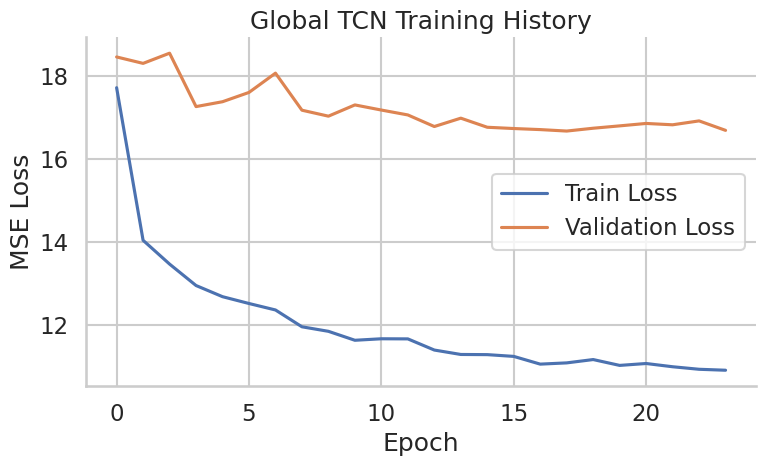

In [127]:
# ============================================================
# CELL 21: Final Global TCN Training
# ============================================================
# Purpose:
# Train the global TCN model, generate validation and test forecasts,
# and apply residual-based drift detection for household monitoring.
# ============================================================

# Define TCN architecture for sequence forecasting
tcn_model = Sequential([
    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        dropout_rate=0.2,
        return_sequences=False
    ),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

tcn_model.compile(optimizer="adam", loss="mse")

# Use early stopping and learning-rate reduction for stable training
callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, verbose=1)
]

tcn_history = tcn_model.fit(
    X_train_tcn, y_train_tcn,
    validation_data=(X_val_tcn, y_val_tcn),
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(tcn_history.history["loss"], label="Train Loss")
plt.plot(tcn_history.history["val_loss"], label="Validation Loss")
plt.title("Global TCN Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Generate validation and test predictions
val_pred_tcn = tcn_model.predict(X_val_tcn, verbose=0).flatten()
test_pred_tcn = tcn_model.predict(X_test_tcn, verbose=0).flatten()

val_global_tcn = meta_val_tcn.copy()
val_global_tcn["daily_kWh"] = y_val_tcn
val_global_tcn["tcn_pred"] = val_pred_tcn
val_global_tcn["tcn_residual"] = val_global_tcn["daily_kWh"] - val_global_tcn["tcn_pred"]

test_global_tcn = meta_test_tcn.copy()
test_global_tcn["daily_kWh"] = y_test_tcn
test_global_tcn["tcn_pred"] = test_pred_tcn
test_global_tcn["tcn_residual"] = test_global_tcn["daily_kWh"] - test_global_tcn["tcn_pred"]

# Attach carbon intensity for downstream environmental impact analysis
test_global_tcn = test_global_tcn.merge(
    test_global[["LCLid", "date", "carbon_intensity"]].drop_duplicates(),
    on=["LCLid", "date"],
    how="left"
)

# Use validation residuals as household-specific drift baselines
tcn_baseline_by_house = {
    hid: g["tcn_residual"].dropna().values
    for hid, g in val_global_tcn.groupby("LCLid")
}

# Apply residual-based drift monitoring on test data
test_global_tcn = apply_drift_methods(
    test_global_tcn,
    "tcn_residual",
    "tcn",
    baseline_by_house=tcn_baseline_by_house
)

# Evaluate forecasting accuracy, alert performance, and carbon impact
tcn_metrics_all = compute_forecast_metrics(
    test_global_tcn, "daily_kWh", "tcn_pred", "TCN"
)
tcn_cusum_eval = evaluate_alerts(
    test_global_tcn, "tcn_cusum_alert", "tcn_residual", "TCN_CUSUM",
    baseline_by_house=tcn_baseline_by_house
)
tcn_ewma_eval = evaluate_alerts(
    test_global_tcn, "tcn_ewma_alert", "tcn_residual", "TCN_EWMA",
    baseline_by_house=tcn_baseline_by_house
)
carbon_tcn = carbon_impact_summary(test_global_tcn, "tcn_residual", "TCN")

In [109]:
# ============================================================
# CELL 22: Global TCN Prediction and Drift Monitoring
# ============================================================
# Purpose:
# Generate TCN forecasts, compute residuals, and apply
# household-level drift monitoring on the test set.
# ============================================================

# Generate validation and test predictions
val_pred_tcn = tcn_model.predict(X_val_tcn, verbose=0).flatten()
test_pred_tcn = tcn_model.predict(X_test_tcn, verbose=0).flatten()

val_global_tcn = meta_val_tcn.copy()
val_global_tcn["daily_kWh"] = y_val_tcn
val_global_tcn["tcn_pred"] = val_pred_tcn
val_global_tcn["tcn_residual"] = val_global_tcn["daily_kWh"] - val_global_tcn["tcn_pred"]

test_global_tcn = meta_test_tcn.copy()
test_global_tcn["daily_kWh"] = y_test_tcn
test_global_tcn["tcn_pred"] = test_pred_tcn
test_global_tcn["tcn_residual"] = test_global_tcn["daily_kWh"] - test_global_tcn["tcn_pred"]

# Attach carbon intensity for environmental impact analysis
test_global_tcn = test_global_tcn.merge(
    test_global[["LCLid", "date", "carbon_intensity"]].drop_duplicates(),
    on=["LCLid", "date"],
    how="left"
)

# Use validation residuals as household-specific drift baselines
tcn_baseline_by_house = {
    hid: g["tcn_residual"].dropna().values
    for hid, g in val_global_tcn.groupby("LCLid")
}

# Apply residual-based drift monitoring on test data
test_global_tcn = apply_drift_methods(
    test_global_tcn,
    "tcn_residual",
    "tcn",
    baseline_by_house=tcn_baseline_by_house
)

# Evaluate forecasting accuracy, alert performance, and carbon impact
tcn_metrics_all = compute_forecast_metrics(
    test_global_tcn, "daily_kWh", "tcn_pred", "TCN"
)
tcn_cusum_eval = evaluate_alerts(
    test_global_tcn, "tcn_cusum_alert", "tcn_residual", "TCN_CUSUM",
    baseline_by_house=tcn_baseline_by_house
)
tcn_ewma_eval = evaluate_alerts(
    test_global_tcn, "tcn_ewma_alert", "tcn_residual", "TCN_EWMA",
    baseline_by_house=tcn_baseline_by_house
)
carbon_tcn = carbon_impact_summary(test_global_tcn, "tcn_residual", "TCN")

In [104]:
import tqdm

# ============================================================
# CELL 23: STL + CUSUM + EWMA for All Selected Households
# ============================================================
# Purpose:
# Apply STL-based baseline estimation and residual drift monitoring
# across all selected households using CUSUM and EWMA.
# ============================================================

def run_stl_for_household(df_home, test_start, val_start, period=7):
    """Run rolling STL baseline estimation and drift monitoring for one household."""
    df_home = df_home.sort_values("date").copy()
    baseline_df = df_home[df_home["date"] < test_start].copy()
    test_df = df_home[df_home["date"] >= test_start].copy()

    # Require sufficient history for STL and a non-empty test segment
    if len(baseline_df) < 90 or len(test_df) == 0:
        return None, None, None

    expected_vals = []
    residuals = []

    # Recompute expected consumption sequentially to mimic pseudo real-time monitoring
    for i in range(len(df_home)):
        current_date = df_home.iloc[i]["date"]

        if current_date < test_start:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        past_df = df_home.iloc[:i].copy()

        if len(past_df) < 60:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        stl_df = stl_baseline(past_df, period=period, min_days=60)

        if stl_df is None:
            expected_vals.append(np.nan)
            residuals.append(np.nan)
            continue

        expected_today = stl_df["expected_kWh"].iloc[-1]
        observed_today = df_home.iloc[i]["daily_kWh"]

        expected_vals.append(expected_today)
        residuals.append(observed_today - expected_today)

    df_home["expected_test"] = expected_vals
    df_home["residual_test"] = residuals

    # Use validation-window residuals as the baseline for drift thresholds
    baseline_residuals = df_home.loc[
        (df_home["date"] >= val_start) & (df_home["date"] < test_start),
        "residual_test"
    ].dropna().values

    home_test = df_home[df_home["date"] >= test_start].copy()
    r = home_test["residual_test"].fillna(0).values

    cusum_pos, cusum_neg, cusum_alert, k, h, _, _ = cusum_drift(
        r,
        baseline_residuals=baseline_residuals
    )
    ewma_vals, ewma_alert, ewma_upper, ewma_lower, _, _ = ewma_drift(
        r,
        baseline_residuals=baseline_residuals
    )

    home_test["cusum_pos"] = cusum_pos
    home_test["cusum_neg"] = cusum_neg
    home_test["cusum_alert"] = cusum_alert
    home_test["cusum_k"] = k
    home_test["cusum_h"] = h
    home_test["ewma"] = ewma_vals
    home_test["ewma_alert"] = ewma_alert
    home_test["ewma_upper"] = ewma_upper
    home_test["ewma_lower"] = ewma_lower

    summary = pd.DataFrame({
        "LCLid": [df_home["LCLid"].iloc[0]],
        "stl_cusum_first_alert": [home_test.loc[home_test["cusum_alert"], "date"].min()],
        "stl_cusum_num_alerts": [int(home_test["cusum_alert"].sum())],
        "stl_ewma_first_alert": [home_test.loc[home_test["ewma_alert"], "date"].min()],
        "stl_ewma_num_alerts": [int(home_test["ewma_alert"].sum())]
    })

    return summary, home_test, baseline_residuals


stl_summaries = []
stl_test_all_list = []
stl_baseline_by_house = {}

for hid in tqdm.tqdm(selected_households, desc="Running STL for households"):
    home_df = merged2_sel[merged2_sel["LCLid"] == hid].copy()

    summary, home_test, baseline_res = run_stl_for_household(
        home_df,
        test_start,
        val_start,
        period=CONFIG["stl_period"]
    )

    if summary is not None:
        stl_summaries.append(summary)
        stl_test_all_list.append(home_test)

        if hid not in stl_baseline_by_house and baseline_res is not None:
            stl_baseline_by_house[hid] = baseline_res

if stl_test_all_list:
    stl_test_all = pd.concat(stl_test_all_list, ignore_index=True)
    stl_all_summaries = pd.concat(stl_summaries, ignore_index=True)

    # Store household-wise STL outputs for later inspection or plotting
    stl_details = {df["LCLid"].iloc[0]: df for df in stl_test_all_list}

    stl_cusum_eval = evaluate_alerts(
        stl_test_all, "cusum_alert", "residual_test", "STL_CUSUM",
        baseline_by_house=stl_baseline_by_house
    )
    stl_ewma_eval = evaluate_alerts(
        stl_test_all, "ewma_alert", "residual_test", "STL_EWMA",
        baseline_by_house=stl_baseline_by_house
    )
    carbon_stl = carbon_impact_summary(stl_test_all, "residual_test", "STL")
else:
    print("No households had enough data for STL analysis.")
    stl_test_all = pd.DataFrame()
    stl_all_summaries = pd.DataFrame()
    stl_cusum_eval = pd.DataFrame()
    stl_ewma_eval = pd.DataFrame()
    carbon_stl = pd.DataFrame()
    stl_details = {}

Running STL for households: 100%|██████████| 267/267 [12:49<00:00,  2.88s/it]


Selected household: MAC000002
Train house shape: (385, 57)
Val house shape: (30, 57)
Test house shape: (60, 57)
LSTM train: (355, 30, 13) (355,)
LSTM val: (30, 30, 13) (30,)
LSTM test: (60, 30, 13) (60,)
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 141.8891 - val_loss: 124.3708 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 105.5133 - val_loss: 74.6062 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69.8723 - val_loss: 49.6741 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 45.5535 - val_loss: 31.2043 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 30.9895 - val_loss: 20.8849 - learning_rate: 0.0010
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 25.0911 - val_loss: 16.2688 - learning_rate: 0.0010
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 22.7769 - val_loss: 14.9106 - learning_rate: 0.0010
Epoch 8/30
12/12

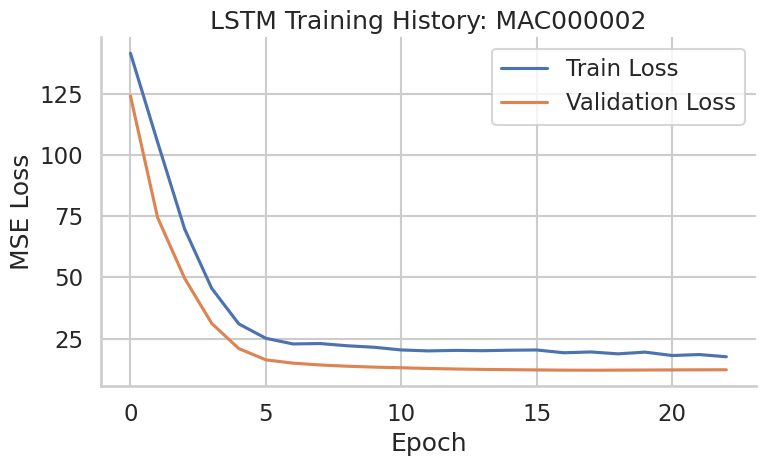

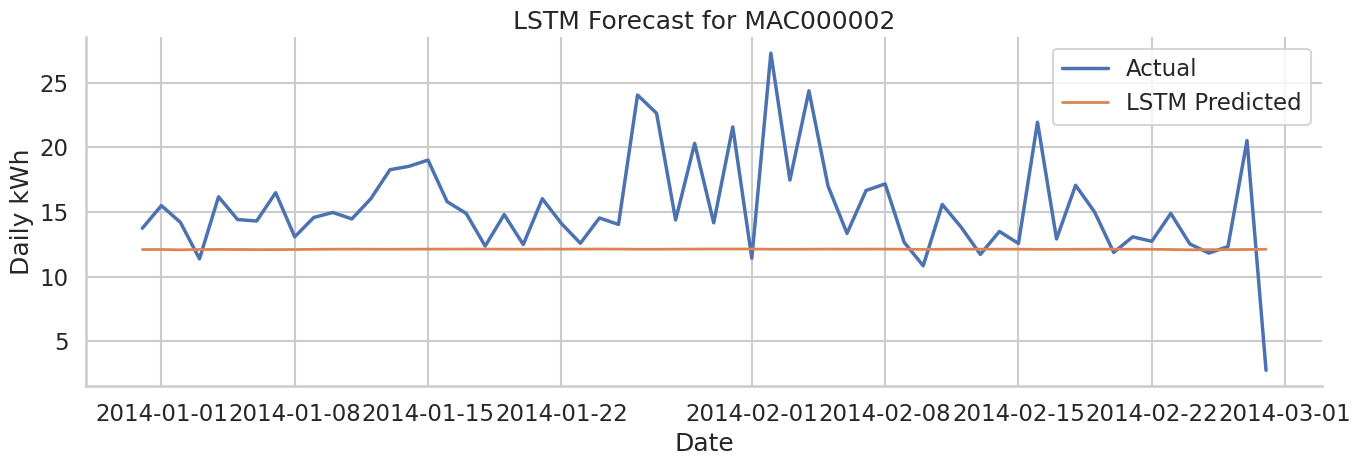

,LCLid,lstm_mae,lstm_rmse,lstm_r2
0,MAC000002,3.625,4.996,-0.688


,LCLid,date,actual,lstm_pred,lstm_error
0,MAC000002,2013-12-31,13.746,12.099,1.647
1,MAC000002,2014-01-01,15.496,12.103,3.393
2,MAC000002,2014-01-02,14.195,12.078,2.117
3,MAC000002,2014-01-03,11.382,12.102,-0.720
4,MAC000002,2014-01-04,16.176,12.107,4.069


In [110]:
# ============================================================
# CELL 24: Local LSTM for Selected Household
# ============================================================
# Purpose:
# Train a household-specific LSTM model for the selected household
# and compare its forecast performance with the global models.
# ============================================================

from tensorflow.keras.layers import LSTM

# Local LSTM settings
LSTM_LOOKBACK = 30
LSTM_EPOCHS = 30
LSTM_BATCH_SIZE = 32

# Use a reduced feature set for household-level sequence modelling
lstm_feature_cols = [
    "daily_kWh",
    "temp_mean",
    "temp_max",
    "temp_min",
    "carbon_intensity",
    "HDD_18",
    "temp_range",
    "is_weekend",
    "is_holiday",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

target_col = "daily_kWh"

# Prepare selected household data
house_df = df_model_sel[df_model_sel["LCLid"] == SELECTED_HOUSE].copy()
house_df["date"] = pd.to_datetime(house_df["date"])
house_df = house_df.sort_values("date").reset_index(drop=True)

train_house = house_df[house_df["date"] < val_start].copy()
val_house = house_df[(house_df["date"] >= val_start) & (house_df["date"] < test_start)].copy()
test_house = house_df[house_df["date"] >= test_start].copy()

print("Selected household:", SELECTED_HOUSE)
print("Train house shape:", train_house.shape)
print("Val house shape:", val_house.shape)
print("Test house shape:", test_house.shape)

# Fit scaler on training data only to avoid leakage
feature_scaler_lstm = StandardScaler()
feature_scaler_lstm.fit(train_house[lstm_feature_cols])


def create_lstm_sequences(df_in, feature_cols, target_col, lookback, scaler):
    """Create rolling input sequences for single-household LSTM forecasting."""
    df_in = df_in.sort_values("date").copy()
    feats = scaler.transform(df_in[feature_cols])
    target = df_in[target_col].values
    dates = df_in["date"].values

    X, y, d = [], [], []

    for i in range(lookback, len(df_in)):
        X.append(feats[i - lookback:i])
        y.append(target[i])
        d.append(dates[i])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        pd.to_datetime(np.array(d))
    )


# Build sequences from the full household history, then split by target date
X_all_lstm, y_all_lstm, d_all_lstm = create_lstm_sequences(
    house_df, lstm_feature_cols, target_col, LSTM_LOOKBACK, feature_scaler_lstm
)

train_mask = d_all_lstm < val_start
val_mask = (d_all_lstm >= val_start) & (d_all_lstm < test_start)
test_mask = d_all_lstm >= test_start

X_train_lstm, y_train_lstm = X_all_lstm[train_mask], y_all_lstm[train_mask]
X_val_lstm, y_val_lstm = X_all_lstm[val_mask], y_all_lstm[val_mask]
X_test_lstm, y_test_lstm = X_all_lstm[test_mask], y_all_lstm[test_mask]
d_test_lstm = d_all_lstm[test_mask]

print("LSTM train:", X_train_lstm.shape, y_train_lstm.shape)
print("LSTM val:", X_val_lstm.shape, y_val_lstm.shape)
print("LSTM test:", X_test_lstm.shape, y_test_lstm.shape)

if len(X_train_lstm) == 0 or len(X_test_lstm) == 0:
    raise ValueError("Not enough sequence data for LSTM. Try a smaller lookback or different household.")

# Define household-specific LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")

lstm_callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, verbose=1)
]

# Train model
lstm_history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=LSTM_EPOCHS,
    batch_size=LSTM_BATCH_SIZE,
    verbose=1,
    callbacks=lstm_callbacks
)

# Predict and evaluate on the test period
lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).flatten()
lstm_metrics = regression_metrics(y_test_lstm, lstm_pred)

lstm_pred_df = pd.DataFrame({
    "LCLid": SELECTED_HOUSE,
    "date": d_test_lstm,
    "actual": y_test_lstm,
    "lstm_pred": lstm_pred,
    "lstm_error": y_test_lstm - lstm_pred
})

print("\nLSTM metrics for selected household:")
print(lstm_metrics)

# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(lstm_history.history["loss"], label="Train Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")
plt.title(f"LSTM Training History: {SELECTED_HOUSE}")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot actual vs predicted consumption
plt.figure(figsize=(14, 5))
plt.plot(lstm_pred_df["date"], lstm_pred_df["actual"], label="Actual", linewidth=2.5)
plt.plot(lstm_pred_df["date"], lstm_pred_df["lstm_pred"], label="LSTM Predicted", linewidth=2)
plt.title(f"LSTM Forecast for {SELECTED_HOUSE}")
plt.xlabel("Date")
plt.ylabel("Daily kWh")
plt.legend()
plt.tight_layout()
plt.show()

# Summarise selected-household LSTM performance
lstm_summary_one = pd.DataFrame({
    "LCLid": [SELECTED_HOUSE],
    "lstm_mae": [lstm_metrics["mae"]],
    "lstm_rmse": [lstm_metrics["rmse"]],
    "lstm_r2": [lstm_metrics["r2"]]
})

display(lstm_summary_one)
display(lstm_pred_df.head())

In [111]:
# ============================================================
# CELL 24: Consolidated Evaluation Tables
# ============================================================
# Purpose:
# Combine forecasting, drift detection, and carbon impact results
# across all models for unified analysis and comparison.
# ============================================================

# Combine forecasting performance metrics
forecast_metrics_all = pd.concat(
    [xgb_metrics_all, rf_metrics_all, tcn_metrics_all],
    ignore_index=True
)

# Combine drift detection evaluation results
drift_eval_all = pd.concat(
    [
        stl_cusum_eval, stl_ewma_eval,
        xgb_cusum_eval, xgb_ewma_eval,
        rf_cusum_eval, rf_ewma_eval,
        tcn_cusum_eval, tcn_ewma_eval
    ],
    ignore_index=True
)

# Combine carbon impact summaries
carbon_all = pd.concat(
    [carbon_stl, carbon_xgb, carbon_rf, carbon_tcn],
    ignore_index=True
)

print("Forecast metrics shape:", forecast_metrics_all.shape)
print("Drift eval shape:", drift_eval_all.shape)
print("Carbon summary shape:", carbon_all.shape)

Forecast metrics shape: (801, 5)
Drift eval shape: (2136, 8)
Carbon summary shape: (1068, 4)


In [113]:
# ============================================================
# CELL 25: Selected Household Detailed Results
# ============================================================
# Purpose:
# Summarise forecasting performance and drift alerts for the
# selected household across all models.
# ============================================================

# Extract selected household results
xgb_one = test_global_xgb[test_global_xgb["LCLid"] == SELECTED_HOUSE].copy()
rf_one = test_global_rf[test_global_rf["LCLid"] == SELECTED_HOUSE].copy()
tcn_one = test_global_tcn[test_global_tcn["LCLid"] == SELECTED_HOUSE].copy()
stl_one = stl_details.get(SELECTED_HOUSE, pd.DataFrame()).copy()

# Compute forecasting metrics
xgb_metrics_one = regression_metrics(xgb_one["daily_kWh"], xgb_one["xgb_pred"]) if len(xgb_one) else None
rf_metrics_one = regression_metrics(rf_one["daily_kWh"], rf_one["rf_pred"]) if len(rf_one) else None
tcn_metrics_one = regression_metrics(tcn_one["daily_kWh"], tcn_one["tcn_pred"]) if len(tcn_one) else None

# Build summary table
selected_house_summary = pd.DataFrame({
    "LCLid": [SELECTED_HOUSE],

    "xgb_mae": [xgb_metrics_one["mae"] if xgb_metrics_one else np.nan],
    "xgb_rmse": [xgb_metrics_one["rmse"] if xgb_metrics_one else np.nan],
    "xgb_r2": [xgb_metrics_one["r2"] if xgb_metrics_one else np.nan],

    "rf_mae": [rf_metrics_one["mae"] if rf_metrics_one else np.nan],
    "rf_rmse": [rf_metrics_one["rmse"] if rf_metrics_one else np.nan],
    "rf_r2": [rf_metrics_one["r2"] if rf_metrics_one else np.nan],

    "tcn_mae": [tcn_metrics_one["mae"] if tcn_metrics_one else np.nan],
    "tcn_rmse": [tcn_metrics_one["rmse"] if tcn_metrics_one else np.nan],
    "tcn_r2": [tcn_metrics_one["r2"] if tcn_metrics_one else np.nan],

    # Drift alerts comparison
    "stl_cusum_alerts": [int(stl_one["cusum_alert"].sum()) if len(stl_one) else 0],
    "stl_ewma_alerts": [int(stl_one["ewma_alert"].sum()) if len(stl_one) else 0],
    "xgb_cusum_alerts": [int(xgb_one["xgb_cusum_alert"].sum()) if len(xgb_one) else 0],
    "rf_cusum_alerts": [int(rf_one["rf_cusum_alert"].sum()) if len(rf_one) else 0],
    "tcn_cusum_alerts": [int(tcn_one["tcn_cusum_alert"].sum()) if len(tcn_one) else 0]
})

selected_house_summary

,LCLid,xgb_mae,xgb_rmse,xgb_r2,rf_mae,rf_rmse,rf_r2,tcn_mae,tcn_rmse,tcn_r2,stl_cusum_alerts,stl_ewma_alerts,xgb_cusum_alerts,rf_cusum_alerts,tcn_cusum_alerts
0,MAC000002,0.201,0.248,0.996,0.295,0.627,0.973,2.970,4.135,-0.156,0,0,0,56,0


In [114]:
# ============================================================
# CELL 26: Final Consolidated Summary Tables
# ============================================================
# Purpose:
# Aggregate forecasting, drift detection, and carbon impact results,
# and compute model-level performance summaries for comparison.
# ============================================================

# Combine forecasting metrics across models
forecast_metrics_all = pd.concat(
    [xgb_metrics_all, rf_metrics_all, tcn_metrics_all],
    ignore_index=True
)

# Combine drift detection evaluation results
drift_eval_all = pd.concat(
    [
        stl_cusum_eval, stl_ewma_eval,
        xgb_cusum_eval, xgb_ewma_eval,
        rf_cusum_eval, rf_ewma_eval,
        tcn_cusum_eval, tcn_ewma_eval
    ],
    ignore_index=True
)

# Combine carbon impact summaries
carbon_all = pd.concat(
    [carbon_stl, carbon_xgb, carbon_rf, carbon_tcn],
    ignore_index=True
)

# Compute overall model performance summary
model_summary = (
    forecast_metrics_all.groupby("model")
    .agg(
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_r2=("r2", "mean")
    )
    .reset_index()
    .sort_values("mean_mae")  # lower MAE = better model
)

print("Forecast metrics shape:", forecast_metrics_all.shape)
print("Drift eval shape:", drift_eval_all.shape)
print("Carbon summary shape:", carbon_all.shape)

print("\nModel Performance Summary:")
print(model_summary)

Forecast metrics shape: (801, 5)
Drift eval shape: (2136, 8)
Carbon summary shape: (1068, 4)

Model Performance Summary:
          model  mean_mae  mean_rmse  mean_r2
2       XGBoost     0.208      0.300    0.874
0  RandomForest     0.288      0.648    0.957
1           TCN     2.395      3.303  -12.385


In [115]:
# ============================================================
# CELL 26.1: Model-Level Forecast Summary
# ============================================================
# Purpose:
# Compute average forecasting performance across households
# to compare overall model effectiveness.
# ============================================================

model_summary = (
    forecast_metrics_all.groupby("model")
    .agg(
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_r2=("r2", "mean")
    )
    .reset_index()
    .sort_values("mean_mae")  # lower MAE indicates better performance
)

model_summary

,model,mean_mae,mean_rmse,mean_r2
2,XGBoost,0.208,0.300,0.874
0,RandomForest,0.288,0.648,0.957
1,TCN,2.395,3.303,-12.385


In [116]:
# ============================================================
# CELL 27: Selected Household Detailed Summary
# ============================================================
# Purpose:
# Compare forecasting performance and drift alerts for the
# selected household across all models.
# ============================================================

# Extract selected household results
xgb_one = test_global_xgb[test_global_xgb["LCLid"] == SELECTED_HOUSE].copy()
rf_one = test_global_rf[test_global_rf["LCLid"] == SELECTED_HOUSE].copy()
tcn_one = test_global_tcn[test_global_tcn["LCLid"] == SELECTED_HOUSE].copy()
stl_one = stl_details.get(SELECTED_HOUSE, pd.DataFrame()).copy()

# Compute forecasting metrics
xgb_metrics_one = regression_metrics(xgb_one["daily_kWh"], xgb_one["xgb_pred"]) if len(xgb_one) else None
rf_metrics_one = regression_metrics(rf_one["daily_kWh"], rf_one["rf_pred"]) if len(rf_one) else None
tcn_metrics_one = regression_metrics(tcn_one["daily_kWh"], tcn_one["tcn_pred"]) if len(tcn_one) else None

# Build comparison summary
selected_house_summary = pd.DataFrame({
    "LCLid": [SELECTED_HOUSE],

    # Forecast performance
    "xgb_mae": [xgb_metrics_one["mae"] if xgb_metrics_one else np.nan],
    "xgb_rmse": [xgb_metrics_one["rmse"] if xgb_metrics_one else np.nan],
    "xgb_r2": [xgb_metrics_one["r2"] if xgb_metrics_one else np.nan],

    "rf_mae": [rf_metrics_one["mae"] if rf_metrics_one else np.nan],
    "rf_rmse": [rf_metrics_one["rmse"] if rf_metrics_one else np.nan],
    "rf_r2": [rf_metrics_one["r2"] if rf_metrics_one else np.nan],

    "tcn_mae": [tcn_metrics_one["mae"] if tcn_metrics_one else np.nan],
    "tcn_rmse": [tcn_metrics_one["rmse"] if tcn_metrics_one else np.nan],
    "tcn_r2": [tcn_metrics_one["r2"] if tcn_metrics_one else np.nan],

    # Drift alert counts
    "stl_cusum_alerts": [int(stl_one["cusum_alert"].sum()) if len(stl_one) else 0],
    "stl_ewma_alerts": [int(stl_one["ewma_alert"].sum()) if len(stl_one) else 0],
    "xgb_cusum_alerts": [int(xgb_one["xgb_cusum_alert"].sum()) if len(xgb_one) else 0],
    "rf_cusum_alerts": [int(rf_one["rf_cusum_alert"].sum()) if len(rf_one) else 0],
    "tcn_cusum_alerts": [int(tcn_one["tcn_cusum_alert"].sum()) if len(tcn_one) else 0]
})

selected_house_summary

,LCLid,xgb_mae,xgb_rmse,xgb_r2,rf_mae,rf_rmse,rf_r2,tcn_mae,tcn_rmse,tcn_r2,stl_cusum_alerts,stl_ewma_alerts,xgb_cusum_alerts,rf_cusum_alerts,tcn_cusum_alerts
0,MAC000002,0.201,0.248,0.996,0.295,0.627,0.973,2.970,4.135,-0.156,0,0,0,56,0


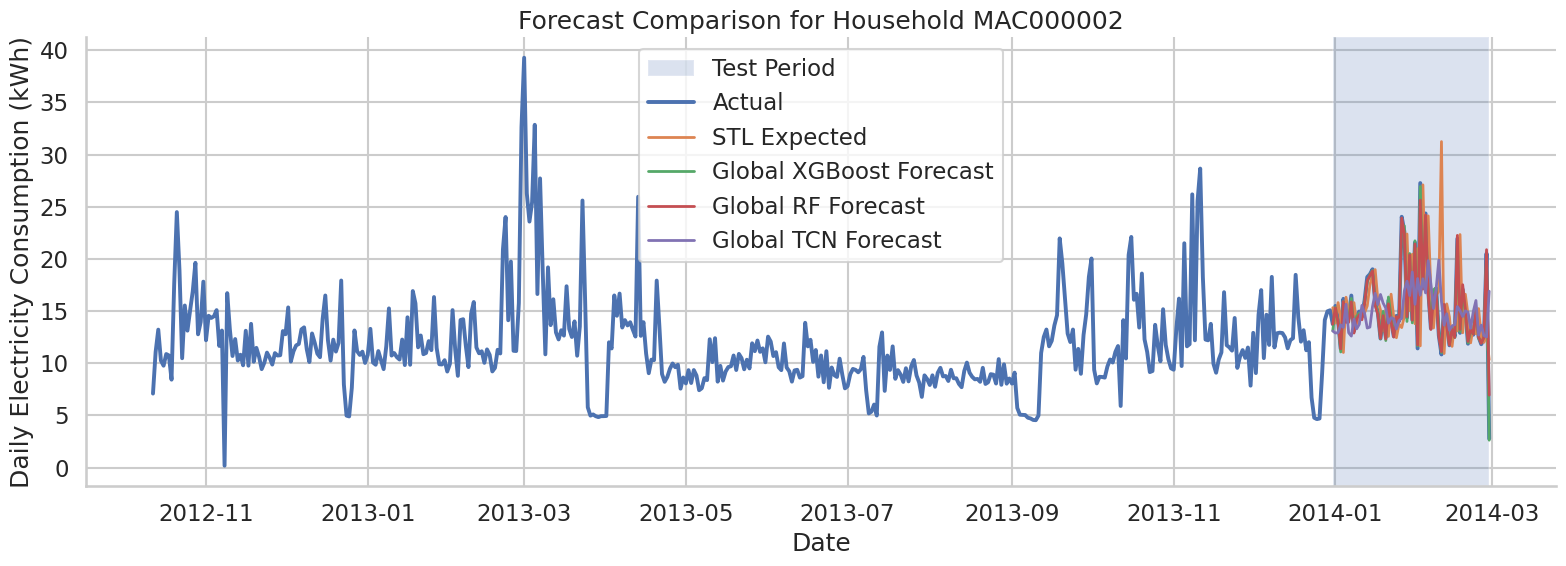

In [117]:
# ============================================================
# CELL 27.1: Forecast Comparison Plot for Selected Household
# ============================================================
# Purpose:
# Compare actual consumption with model forecasts and STL baseline
# for the selected household over time.
# ============================================================

raw_one_house = (
    merged2_sel[merged2_sel["LCLid"] == SELECTED_HOUSE]
    .copy()
    .sort_values("date")
)

plt.figure(figsize=(16, 6))

# Highlight test period
plt.axvspan(test_start, raw_one_house["date"].max(), alpha=0.2, label="Test Period")

# Plot actual consumption
plt.plot(raw_one_house["date"], raw_one_house["daily_kWh"], label="Actual", linewidth=2.8)

# Plot model forecasts if available
if len(stl_one):
    plt.plot(stl_one["date"], stl_one["expected_test"], label="STL Expected", linewidth=2)

if len(xgb_one):
    plt.plot(xgb_one["date"], xgb_one["xgb_pred"], label="Global XGBoost Forecast", linewidth=2)

if len(rf_one):
    plt.plot(rf_one["date"], rf_one["rf_pred"], label="Global RF Forecast", linewidth=2)

if len(tcn_one):
    plt.plot(tcn_one["date"], tcn_one["tcn_pred"], label="Global TCN Forecast", linewidth=2)

plt.title(f"Forecast Comparison for Household {SELECTED_HOUSE}")
plt.xlabel("Date")
plt.ylabel("Daily Electricity Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

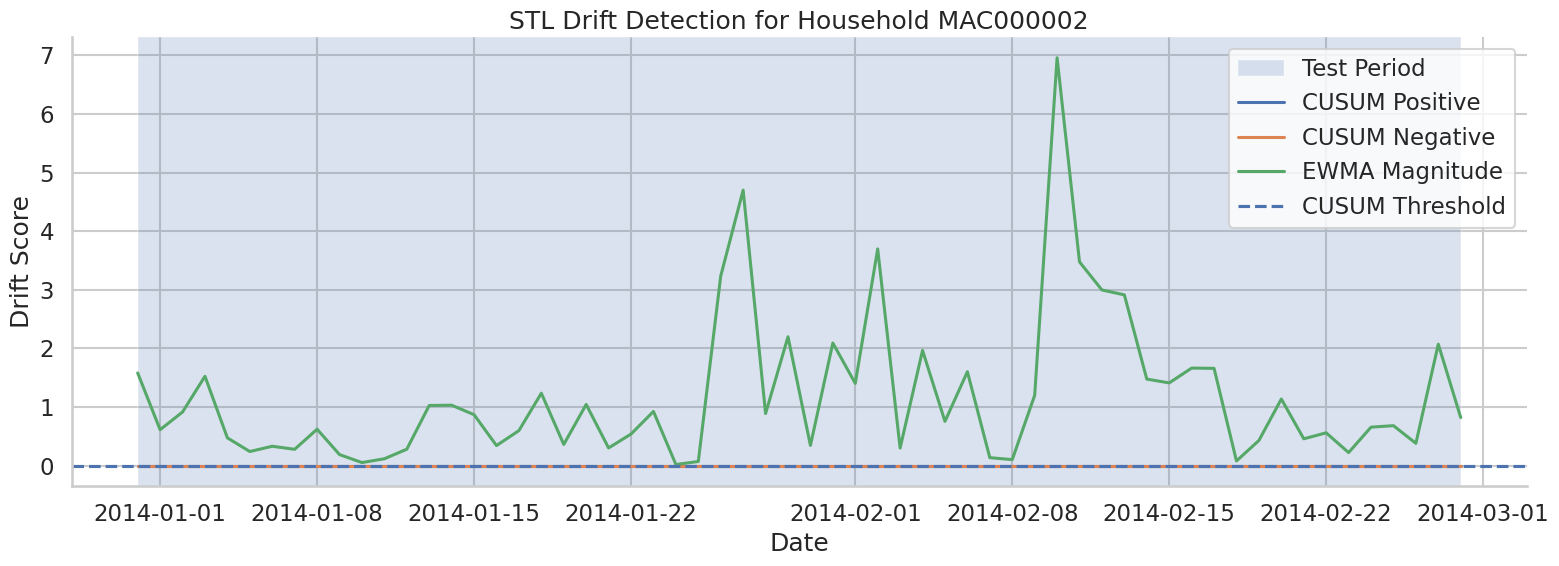

In [118]:
# ============================================================
# CELL 27.2: STL Drift Plot for Selected Household
# ============================================================
# Purpose:
# Visualise STL-based drift signals and control thresholds for
# the selected household during the test period.
# ============================================================

if len(stl_one):
    plt.figure(figsize=(16, 6))

    # Highlight test period
    plt.axvspan(test_start, stl_one["date"].max(), alpha=0.2, label="Test Period")

    # Plot drift signals
    plt.plot(stl_one["date"], stl_one["cusum_pos"], label="CUSUM Positive", linewidth=2.2)
    plt.plot(stl_one["date"], np.abs(stl_one["cusum_neg"]), label="CUSUM Negative", linewidth=2.2)
    plt.plot(stl_one["date"], np.abs(stl_one["ewma"]), label="EWMA Magnitude", linewidth=2.2)

    # Plot decision thresholds when available
    if "cusum_h" in stl_one.columns:
        plt.axhline(stl_one["cusum_h"].iloc[0], linestyle="--", label="CUSUM Threshold")

    if "ewma_upper" in stl_one.columns and pd.notna(stl_one["ewma_upper"].iloc[0]):
        plt.axhline(abs(stl_one["ewma_upper"].iloc[0]), linestyle=":", label="EWMA Threshold")

    plt.title(f"STL Drift Detection for Household {SELECTED_HOUSE}")
    plt.xlabel("Date")
    plt.ylabel("Drift Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

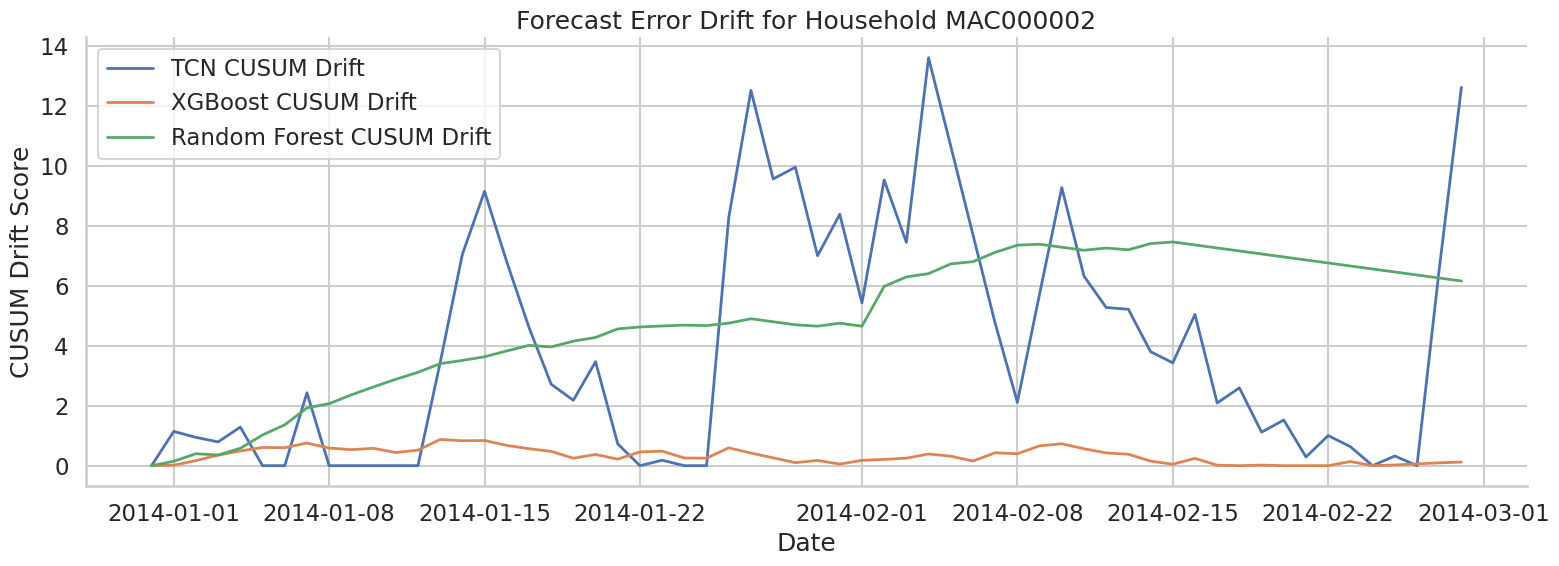

In [119]:
# ============================================================
# CELL 27.3: Forecast Error Drift Plot for Selected Household
# ============================================================
# Purpose:
# Compare residual-based drift signals across models for the
# selected household.
# ============================================================

plt.figure(figsize=(16, 6))

# Plot CUSUM drift magnitude (captures both upward and downward drift)
if len(tcn_one):
    plt.plot(
        tcn_one["date"],
        np.abs(tcn_one["tcn_cusum_pos"]) + np.abs(tcn_one["tcn_cusum_neg"]),
        label="TCN CUSUM Drift",
        linewidth=2
    )

if len(xgb_one):
    plt.plot(
        xgb_one["date"],
        np.abs(xgb_one["xgb_cusum_pos"]) + np.abs(xgb_one["xgb_cusum_neg"]),
        label="XGBoost CUSUM Drift",
        linewidth=2
    )

if len(rf_one):
    plt.plot(
        rf_one["date"],
        np.abs(rf_one["rf_cusum_pos"]) + np.abs(rf_one["rf_cusum_neg"]),
        label="Random Forest CUSUM Drift",
        linewidth=2
    )

plt.title(f"Forecast Error Drift for Household {SELECTED_HOUSE}")
plt.xlabel("Date")
plt.ylabel("CUSUM Drift Score")
plt.legend()
plt.tight_layout()
plt.show()

In [120]:
# ============================================================
# CELL 28: Multi-Household Comparison Table
# ============================================================
# Purpose:
# Build a household-level comparison table combining forecast
# performance, drift alerts, and carbon impact across models.
# ============================================================

compare_households = selected_households[:CONFIG["max_compare_houses"]]

def alert_count_by_house(df_, alert_col):
    """Count alerts per household for a given drift signal."""
    return (
        df_.groupby("LCLid")[alert_col]
        .sum()
        .reset_index()
        .rename(columns={alert_col: f"{alert_col}_count"})
    )

comparison = pd.DataFrame({"LCLid": compare_households})

# Merge household-level alert counts from all drift methods
for df_, col in [
    (stl_test_all, "cusum_alert"),
    (stl_test_all, "ewma_alert"),
    (test_global_xgb, "xgb_cusum_alert"),
    (test_global_xgb, "xgb_ewma_alert"),
    (test_global_rf, "rf_cusum_alert"),
    (test_global_rf, "rf_ewma_alert"),
    (test_global_tcn, "tcn_cusum_alert"),
    (test_global_tcn, "tcn_ewma_alert")
]:
    comparison = comparison.merge(alert_count_by_house(df_, col), on="LCLid", how="left")

# Reshape forecast metrics to one row per household
metric_wide = forecast_metrics_all.pivot(index="LCLid", columns="model", values=["mae", "rmse", "r2"])
metric_wide.columns = [f"{a}_{b}" for a, b in metric_wide.columns]
metric_wide = metric_wide.reset_index()
comparison = comparison.merge(metric_wide, on="LCLid", how="left")

# Reshape carbon impact to one row per household
carbon_wide = carbon_all.pivot(index="LCLid", columns="model", values="excess_carbon_g").reset_index()
carbon_wide.columns = ["LCLid" if c == "LCLid" else f"carbon_{c}" for c in carbon_wide.columns]
comparison = comparison.merge(carbon_wide, on="LCLid", how="left")

comparison.fillna(0, inplace=True)
comparison

,LCLid,cusum_alert_count,ewma_alert_count,xgb_cusum_alert_count,xgb_ewma_alert_count,rf_cusum_alert_count,rf_ewma_alert_count,tcn_cusum_alert_count,tcn_ewma_alert_count,mae_RandomForest,mae_TCN,mae_XGBoost,rmse_RandomForest,rmse_TCN,rmse_XGBoost,r2_RandomForest,r2_TCN,r2_XGBoost,carbon_RandomForest,carbon_STL,carbon_TCN,carbon_XGBoost
0,MAC000002,0,0,0,6,56,42,0,1,0.295,2.970,0.201,0.627,4.135,0.248,0.973,-0.156,0.996,"4,585.608","50,529.931","43,877.053","3,313.619"
1,MAC000003,0,0,8,3,34,11,0,0,0.740,7.149,0.369,1.091,8.890,0.488,0.989,0.267,0.998,"9,315.110","102,731.334","101,071.071","3,915.365"
2,MAC000004,0,0,3,2,1,4,6,2,0.036,0.456,0.071,0.104,0.537,0.083,0.787,-4.688,0.864,388.552,"1,542.427",11.644,"1,289.328"
3,MAC000006,0,0,8,6,54,33,0,4,0.060,0.454,0.096,0.169,0.647,0.130,0.901,-0.447,0.942,287.537,"5,127.038","2,803.669","1,345.379"
4,MAC000007,0,0,0,0,1,1,0,0,0.286,3.115,0.160,0.539,4.585,0.238,0.985,-0.069,0.997,974.447,"49,883.945","35,242.005","1,874.742"
5,MAC000009,0,0,1,1,13,8,0,1,0.123,1.166,0.089,0.383,1.677,0.118,0.953,0.092,0.996,"1,251.620","16,809.470","10,230.317","1,698.755"
6,MAC000010,0,0,0,0,37,5,0,1,0.555,4.290,0.431,1.357,5.630,0.513,0.961,0.333,0.994,"3,672.412","56,412.331","57,624.498","6,146.966"
7,MAC000011,0,0,10,0,37,20,0,2,0.187,2.558,0.136,0.475,3.550,0.170,0.980,-0.125,0.997,"1,872.135","34,105.953","32,210.504","1,657.293"
8,MAC000012,0,0,3,1,1,1,44,2,0.039,0.642,0.073,0.105,0.683,0.103,0.779,-8.377,0.786,419.601,"1,577.643",320.048,527.570
9,MAC000013,0,0,13,4,55,24,0,1,0.095,0.667,0.091,0.274,0.997,0.153,0.935,0.144,0.980,439.459,"7,838.316","5,055.061",857.358


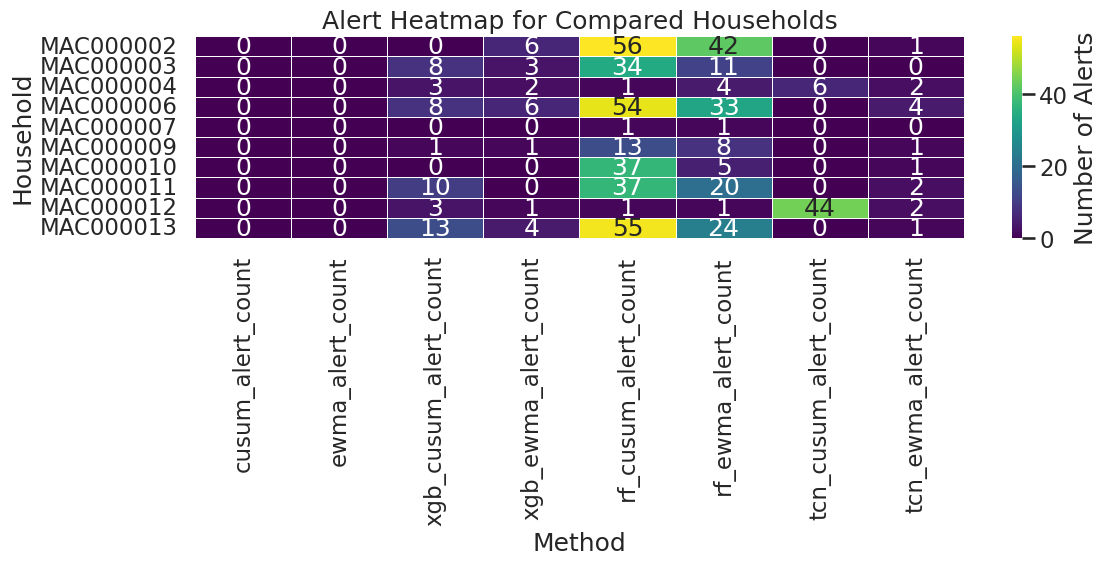

In [121]:
# ============================================================
# CELL 28.1: Alert Heatmap for Compared Households
# ============================================================
# Purpose:
# Visualise and compare drift alert counts across households
# and detection methods.
# ============================================================

heat_cols = [
    "cusum_alert_count", "ewma_alert_count",
    "xgb_cusum_alert_count", "xgb_ewma_alert_count",
    "rf_cusum_alert_count", "rf_ewma_alert_count",
    "tcn_cusum_alert_count", "tcn_ewma_alert_count"
]

heatmap_df = comparison[["LCLid"] + heat_cols].set_index("LCLid")

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Number of Alerts"}
)

plt.title("Alert Heatmap for Compared Households")
plt.xlabel("Method")
plt.ylabel("Household")

plt.tight_layout()
plt.show()

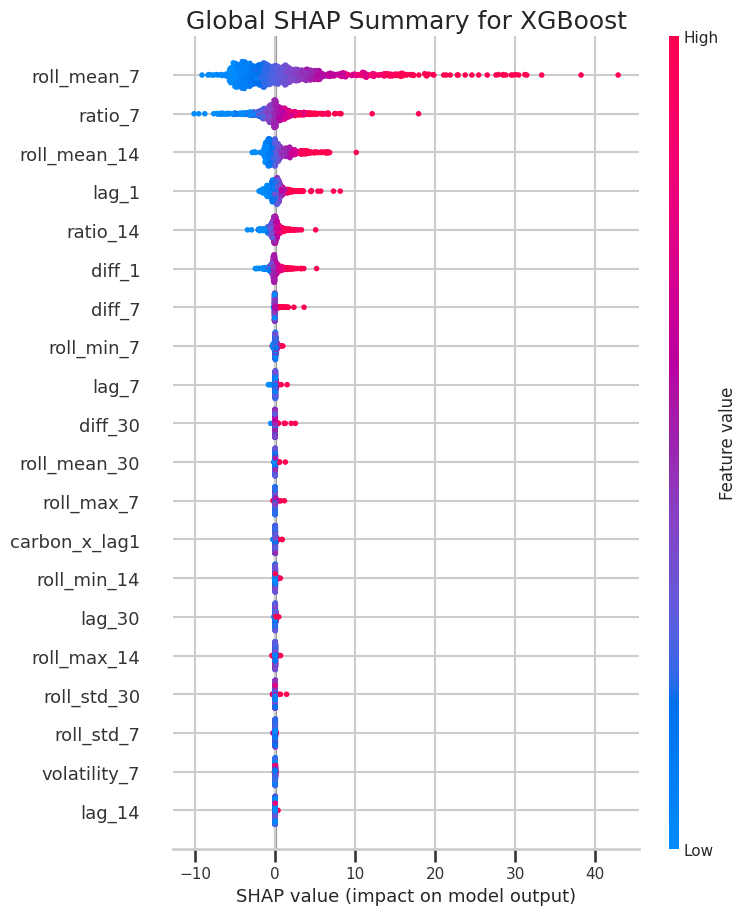

In [122]:
# ============================================================
# CELL 29: Global SHAP for XGBoost
# ============================================================
# Purpose:
# Interpret global feature importance of the XGBoost model
# using SHAP values on a representative test sample.
# ============================================================

# Sample test data for efficient SHAP computation
X_test_xgb_sample = test_global[feature_cols].sample(
    min(1000, len(test_global)),
    random_state=42
)

explainer = shap.Explainer(global_xgb)
shap_values = explainer(X_test_xgb_sample)

# Visualise global feature importance
shap.summary_plot(shap_values, X_test_xgb_sample, show=False)
plt.title("Global SHAP Summary for XGBoost")
plt.tight_layout()
plt.show()

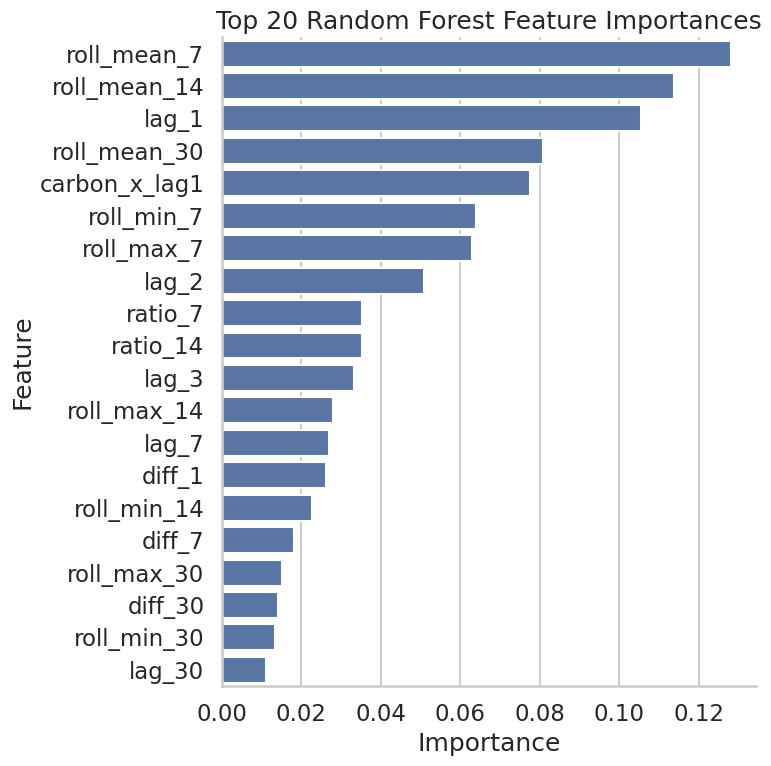

In [123]:
# ============================================================
# CELL 30: Global RF Feature Importance
# ============================================================
# Purpose:
# Visualise the most important features used by the Random Forest
# model for predicting electricity consumption.
# ============================================================

rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": global_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(
    data=rf_importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

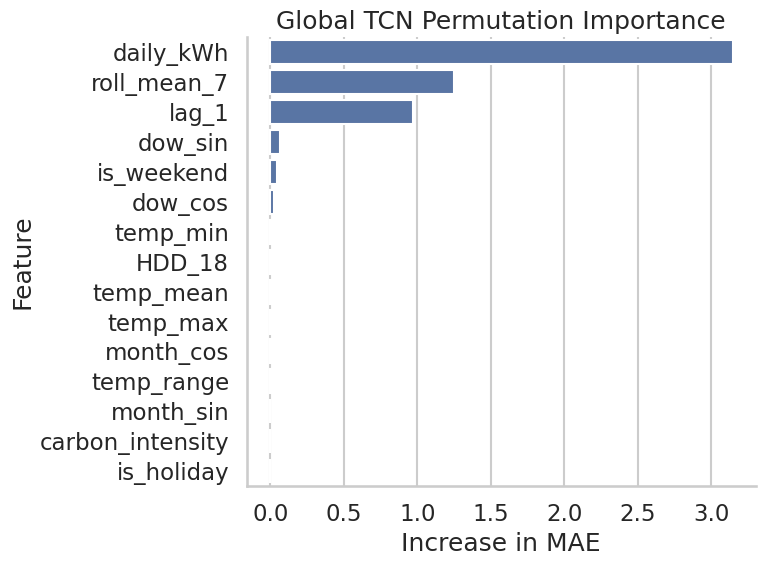

In [124]:
# ============================================================
# CELL: Global TCN Permutation Importance
# ============================================================

def tcn_permutation_importance_global(model, X_sample, y_sample, feature_names):
    baseline_pred = model.predict(X_sample, verbose=0).flatten()
    baseline_error = mean_absolute_error(y_sample, baseline_pred)

    importances = []
    for f_idx, f_name in enumerate(feature_names):
        X_perm = X_sample.copy()
        np.random.shuffle(X_perm[:, :, f_idx])
        pred = model.predict(X_perm, verbose=0).flatten()
        err = mean_absolute_error(y_sample, pred)
        importances.append(err - baseline_error)

    return pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

sample_idx = np.random.choice(len(X_test_tcn), size=min(2000, len(X_test_tcn)), replace=False)
perm_df = tcn_permutation_importance_global(
    tcn_model,
    X_test_tcn[sample_idx],
    y_test_tcn[sample_idx],
    seq_feature_cols
)

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df.head(15), x="importance", y="feature")
plt.title("Global TCN Permutation Importance")
plt.xlabel("Increase in MAE")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

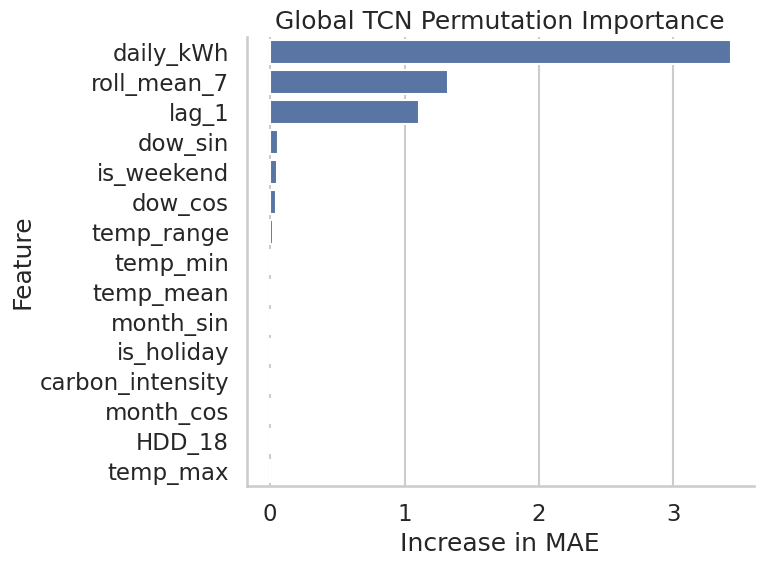

In [125]:
# ============================================================
# CELL 31: Global TCN Permutation Importance
# ============================================================
# Purpose:
# Estimate feature importance for the TCN model by measuring
# the increase in prediction error when each feature is shuffled.
# ============================================================

def tcn_permutation_importance_global(model, X_sample, y_sample, feature_names):
    """Compute permutation importance based on MAE increase."""

    baseline_pred = model.predict(X_sample, verbose=0).flatten()
    baseline_error = mean_absolute_error(y_sample, baseline_pred)

    importances = []

    for f_idx, f_name in enumerate(feature_names):
        X_perm = X_sample.copy()

        # Shuffle one feature across all sequences (breaks its information)
        np.random.shuffle(X_perm[:, :, f_idx])

        pred = model.predict(X_perm, verbose=0).flatten()
        err = mean_absolute_error(y_sample, pred)

        importances.append(err - baseline_error)

    return pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)


# Sample test sequences for efficiency
sample_idx = np.random.choice(
    len(X_test_tcn),
    size=min(2000, len(X_test_tcn)),
    replace=False
)

perm_df = tcn_permutation_importance_global(
    tcn_model,
    X_test_tcn[sample_idx],
    y_test_tcn[sample_idx],
    seq_feature_cols
)

# Visualise most important features
plt.figure(figsize=(8, 6))
sns.barplot(
    data=perm_df.head(15),
    x="importance",
    y="feature"
)

plt.title("Global TCN Permutation Importance")
plt.xlabel("Increase in MAE")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [126]:
# ============================================================
# CELL 32: Final Summary Prints
# ============================================================
# Purpose:
# Display final model performance, carbon impact, and
# household-level comparison summaries.
# ============================================================

print("\n========== MODEL SUMMARY ==========")
print(model_summary)

# Aggregate carbon impact at model level
carbon_model_summary = (
    carbon_all.groupby("model")
    .agg(mean_excess_carbon_g=("excess_carbon_g", "mean"))
    .reset_index()
    .sort_values("mean_excess_carbon_g", ascending=False)
)

print("\n========== CARBON SUMMARY ==========")
print(carbon_model_summary)

print("\n========== SELECTED HOUSE SUMMARY ==========")
print(selected_house_summary)

print("\n========== COMPARED HOUSEHOLDS ==========")
print(comparison[["LCLid"]].head(CONFIG["max_compare_houses"]))


========== MODEL SUMMARY ==========
          model  mean_mae  mean_rmse  mean_r2
2       XGBoost     0.208      0.300    0.874
0  RandomForest     0.288      0.648    0.957
1           TCN     2.395      3.303  -12.385

========== CARBON SUMMARY ==========
          model  mean_excess_carbon_g
1           STL            36,321.397
2           TCN            31,342.589
0  RandomForest             3,442.181
3       XGBoost             2,460.219

========== SELECTED HOUSE SUMMARY ==========
       LCLid  xgb_mae  xgb_rmse  xgb_r2  rf_mae  rf_rmse  rf_r2  tcn_mae  \
0  MAC000002    0.201     0.248   0.996   0.295    0.627  0.973    2.970   

   tcn_rmse  tcn_r2  stl_cusum_alerts  stl_ewma_alerts  xgb_cusum_alerts  \
0     4.135  -0.156                 0                0                 0   

   rf_cusum_alerts  tcn_cusum_alerts  
0               56                 0  

========== COMPARED HOUSEHOLDS ==========
       LCLid
0  MAC000002
1  MAC000003
2  MAC000004
3  MAC000006
4  MAC000007
